In [1]:
%matplotlib ipympl
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import FontProperties
from scipy.special import genlaguerre    #genlaguerre(n, alpha)
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.pyplot import MultipleLocator

from matplotlib.lines import Line2D
import ipywidgets as widgets
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

In [2]:
#數值設定  
c = 299792458 #m/s
Eg = 1.7 #eV
D_B = 1.89 * 10**(-20) #um*C
D_G = 0.12 * 10**(-20) #um*C
a_0 = 1 #V*s
ZR = 11.81 #um
W = 1.5 #umz
Q_c = 8.6 #um^-1
q = 2*ZR/(W**2) #um-1
w = c*q*10**(-6)
hbar = 6.582119569 * 10**(-16) #eV*s
print("q=",q,"um-1$ \nw=",w,"s^-1 \nLamda=",2*np.pi/q,"um")

def Factorial(n):
    f=1
    for i in range(1,n+1,1):
        f*=i 
    return f

def Laguerre(rho,l,p):
    l = np.abs(l)
    L = 0
    for m in range(p+1):
        L += (-1)**m * Factorial(l+p) / (Factorial(p-m)*Factorial(l+m)*Factorial(m)) * (2*(rho/W)**2)**m
    return L

def f(rho,l,p):
    l = np.abs(l)
    f = np.sqrt((Factorial(p)*2)/(np.pi*Factorial(l+p))) * np.exp(-(rho/W)**2) * (np.sqrt(2)*rho/W)**l * Laguerre(rho,l,p)
    return f 
    
def u(phi,rho,l,p):
    u = f(rho,l,p) * np.exp(complex(0,1)*l*phi)
    return u

q= 10.497777777777777 um-1$ 
w= 3147.154603537778 s^-1 
Lamda= 0.5985252726991562 um


In [3]:
Lambda = 0.532 #um
q_0 = 2*np.pi/Lambda # um-1
w = c*q*10**(-6)
W = 1.5 #um
ZR = 1/2 * q * (W**2) # um-1
print(q, w, ZR)

10.497777777777777 3147.154603537778 11.809999999999999


In [4]:
number=20
def B(l, q, rho):
    l = np.abs(l)
    B = 0
    for i in range(0,number+1,1):
        B = B + (-(q*rho)**2/4)**i / (Factorial(i)*Factorial(l+i))
        # B += rho / Factorial(i)
        
    B *= (q*rho/2)**l
    return B

In [5]:
def fun(q,rho,l,p):
        y = rho*B(l,q,rho)*f(rho,l,p)
        return y

In [305]:
h=0.001
p=0
def H(q,l):
    # h = np.power(0.1,3)
    max = 3.5
    min = 0
    
    sim = 0
    rho = min+h/2
    while (rho<max):
        sim += h/6 * (fun(q, rho-h/2, l, p)+4*fun(q, rho, l, p)+fun(q, rho+h/2, l, p))
        rho += h
    
    return sim

In [306]:
H(q=1,l=0)

0.5129524484670841

In [121]:
gamma = 2.94/2

def integral(q, phiq, l):
    int = np.abs(2*np.pi*(-complex(0,1))**np.abs(l)*H(q,l)*np.exp(complex(0,1)*l*phiq))**2 * np.abs(gamma*np.abs(q)*np.exp(2*complex(0,1)*phiq))**2
    return int

h2=0.01
def int_phiq(q, l):
    max = 2*np.pi
    min = 0
    sim2 = 0
    phiq = min+h2/2
    while (phiq<max):
        sim2 += h2/6 * (integral(q, phiq-h2/2, l)+4*integral(q, phiq, l)+integral(q, phiq+h2/2, l))
        phiq += h2
    return sim2

h3=0.01
def int_q(l):
    max = 15
    min = 0
    sim3 = 0
    q    = min+h3/2
    while (q<max):
        sim3+= h3/6 * (int_phiq(q-h3/2, l)+4*int_phiq(q, l)+int_phiq(q+h3/2, l))
        q   += h3
    return sim3

In [122]:
def tau(l):
    l = np.abs(l)
    Tau = 1 / int_q(l)
    return Tau

In [ ]:
fig, ax = plt.subplots()

taul = []
for l in range(0,3,1):
    taul += [tau(l)]

ax.plot( np.arange(0,3,1), taul, 'o',color='black' )
for i, v in enumerate(taul):
        ax.text(i+0.25, v+0.01, "%2.2f" %v, ha="center")    
    
ax.grid()
ax.set_xlabel('$\ell$', fontsize=16)
ax.set_ylabel('$τ_{KK\'}^{\ell}/τ_{KK\'}^{\ell=0}$', fontsize=16)
ax.set_xlim(-0.8, 6.8)
plt.show()

In [147]:
def A(phiq,q,l,p):
    A = np.abs(2*np.pi*(-complex(0,1))**np.abs(l)*H(q,l)*np.exp(complex(0,1)*l*phiq))**2
    return A

0


NameError: name 'H' is not defined

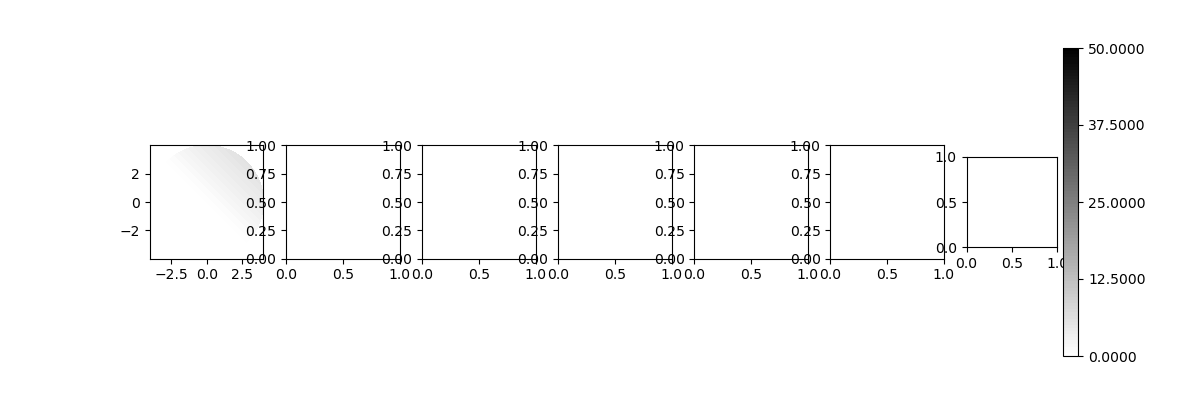

In [148]:
fig, ax = plt.subplots(1,7,figsize=(12, 4))
for s in range(7):
    ax[s].set_aspect('equal', adjustable='box')
    ax[s].set_box_aspect(1)
    
R=4
LIM = 50
q = np.linspace(0, R, 4)
phiq = np.linspace(0, 2*np.pi, 100)
#計算2D資料
q, phiq = np.meshgrid(q, phiq)
x, y = q*np.cos(phiq), q*np.sin(phiq)
p=0
fig.colorbar(ax[0].contourf(x, y, (x+y), levels=np.linspace(0,LIM,100), cmap='gist_yarg'), ax=ax[6], format="{x:.4f}", ticks=np.linspace(0,LIM, 5))

for s in range(6):
    l = s
    print(s)
    ax[s].contourf(x, y, A(phiq,q,l,p), levels=np.linspace(0,LIM,100), cmap='gist_yarg')
    
    
ax[0].set_xlabel('q$_{x}$')
ax[0].set_ylabel('q$_{y}$',rotation=0)

plt.tight_layout()
plt.show()  

In [ ]:
---------------------------------------------------------------------------------------------------------------------------------------

In [4]:
def uanalytic(phiq,q,l):
    uanalytic = (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) * np.exp(complex(0,1)*l*phiq)
    return uanalytic

In [5]:
p=0
gamma = 2.94/2
def integral(q, phiq, l):
    int = np.abs(uanalytic(phiq,q,l))**2 * np.abs(gamma*np.abs(q)*np.exp(2*complex(0,1)*phiq))**2
    return int

h2=0.01
def int_phiq(q, l):
    max = 2*np.pi
    min = 0
    sim2 = 0
    phiq = min+h2/2
    while (phiq<max):
        sim2 += h2/6 * (integral(q, phiq-h2/2, l)+4*integral(q, phiq, l)+integral(q, phiq+h2/2, l))
        phiq += h2
    return sim2

# def int_phiq(q, l):
#     sim2 = 2*np.pi *q* np.abs( (-complex(0,1))**np.abs(l) * np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4))**2 * np.abs(gamma*q)**2
#     return sim2

h3=0.01
def int_q(l):
    max = 4
    min = 0
    sim3 = 0
    q    = min+h3/2
    while (q<max):
        sim3+= h3/6 * (int_phiq(q-h3/2, l)*(q-h3)+4*int_phiq(q, l)*q+int_phiq(q+h3/2, l)*(q+h3))
        q   += h3
    return sim3

def tau(l):
    l = np.abs(l)
    Tau = 1 / int_q(l)
    return Tau

In [6]:
def tau_mathematica(l):
    l = np.abs(l)
    Tau = 1 / ( 4*np.pi*gamma**2*Factorial(l+1)*(2*np.pi/Factorial(l)) )
    return Tau

KeyboardInterrupt: 

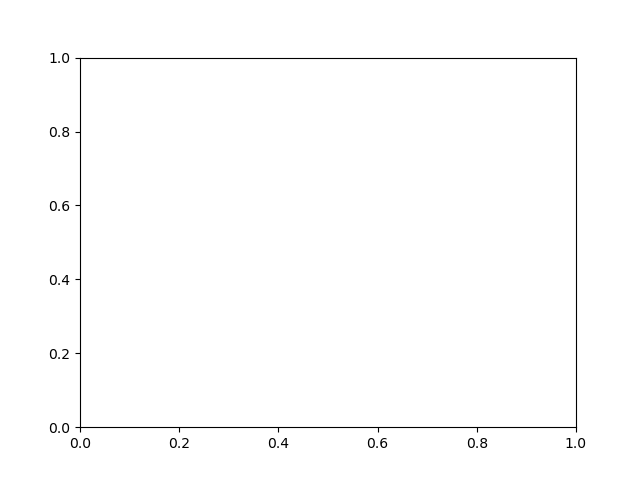

In [7]:
fig, ax = plt.subplots()

taul = []
taul_mathmetica = []
for l in range(0,7,1):
    taul += [tau(l)]
    taul_mathmetica += [tau_mathematica(l)]

ax.plot( np.arange(0,7,1), taul, markersize=8, marker='o', linewidth=0, color='red' )  
# ax.plot( np.arange(0,7,1), taul_mathmetica, markersize=3, marker='o', linewidth=0, color='blue' )  
    
ax.plot( np.arange(0,7,1), tau(0)/(np.abs(np.arange(0,7,1))+1), 'x', markersize=8, color='black')

ax.grid()
ax.set_xlabel('$\ell$', fontsize=16)
ax.set_ylabel('$τ_{KK\'}^{\ell}/τ_{KK\'}^{\ell=0}$', fontsize=16)
ax.set_xlim(-0.8, 6.8)
plt.show()

In [ ]:
np.arange(0,7,1)

In [295]:
def uanalytic(phiq,q,l):
    uanalytic = (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) * np.exp(complex(0,1)*l*phiq)
    return uanalytic

def A(phiq,q,l):
    A = np.abs(uanalytic(phiq,q,l)/5.65)**2
    return A

0
1
2
3
4


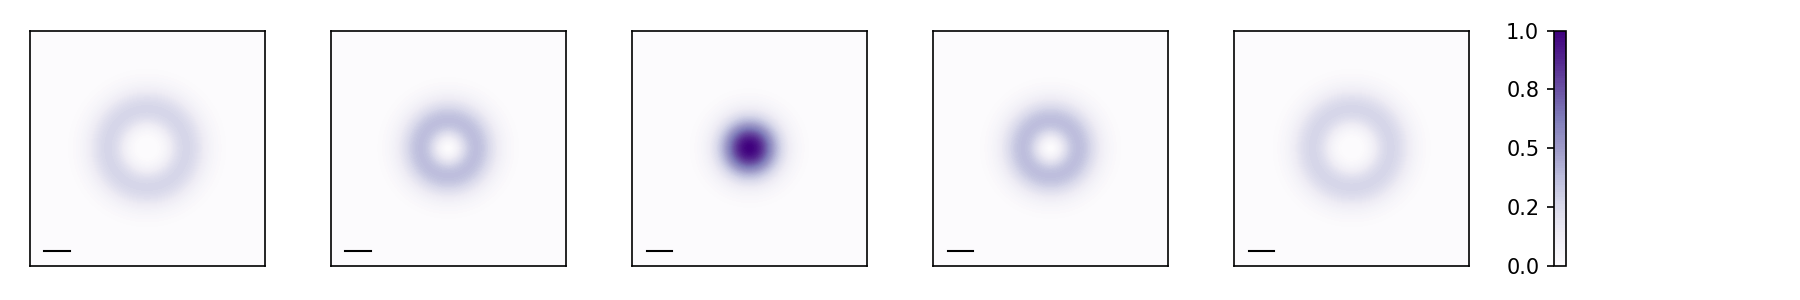

In [297]:
fig, ax = plt.subplots(1,6,figsize=(12, 2), dpi=150)
for s in range(6):
    ax[s].set_aspect('equal', adjustable='box')
    ax[s].set_box_aspect(1)
fig.delaxes(ax[5])

R=1.2*Q_c
LIM = 1
q = np.linspace(0, R, 500)
phiq = np.linspace(0, 2*np.pi, 500)

#計算2D資料
q, phiq = np.meshgrid(q, phiq)
x, y = q*np.cos(phiq), q*np.sin(phiq)
fig.colorbar(ax[0].contourf(x, y, (x+y), levels=np.linspace(0,LIM,100), cmap='Purples'), ax=ax[5], format="{x:.1f}", ticks=np.linspace(0,LIM, 5), location='left')
# fig.colorbar(ax[0].contourf(x, y, (x+y), levels=np.linspace(0,LIM,100), cmap='Oranges'), ax=ax[5], format="{x:.1f}", ticks=np.linspace(0,LIM, 5), location='left')
for s in range(5):
    l = s-2
    print(s)
    ax[s].contourf(x, y, A(phiq,q,l), levels=np.linspace(0,LIM,100), cmap='Purples')
    # ax[s].contourf(x, y, A(phiq,q,l), levels=np.linspace(0,LIM,100), cmap='Oranges')
    ax[s].add_line(Line2D(np.linspace(-3.5, -3.5+0.86, 50),np.linspace(-3.5, -3.5, 50) ,linewidth=1, linestyle='-', color='black'))
    ax[s].set_xticks(np.arange(-4, 6, 2))
    ax[s].set_yticks(np.arange(-4, 6, 2))
    ax[s].set_xlim(-4, 4)
    ax[s].set_ylim(-4, 4)
    ax[s].set_xticks([])
    ax[s].set_yticks([])
    
    
# ax[0].set_xlabel('q$_{x}$')
# ax[0].set_ylabel('q$_{y}$',rotation=0)
# ax[0].annotate("0.1 Q$_c$", xy=(0.05, 0.1),xycoords=ax[0])
plt.tight_layout()
plt.show()    

In [298]:
def uanalytic(phiq,q,l):
    uanalytic = (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) * np.exp(complex(0,1)*l*phiq)
    return uanalytic

def A(phiq,q,l):
    A = np.real(uanalytic(phiq,q,l)/5.65)
    return A

0
1
2
3
4


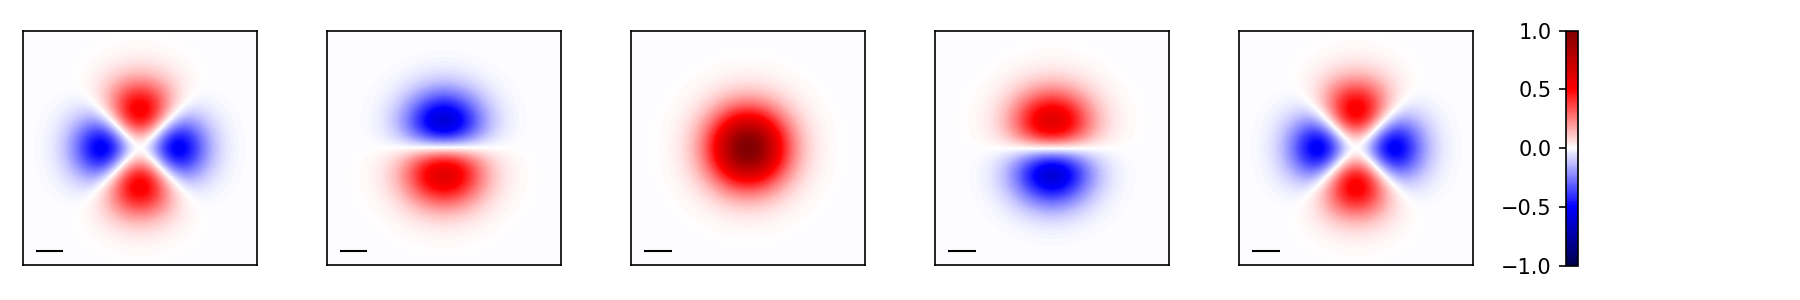

In [299]:
fig, ax = plt.subplots(1,6,figsize=(12, 2), dpi=150)
for s in range(6):
    ax[s].set_aspect('equal', adjustable='box')
    ax[s].set_box_aspect(1)
fig.delaxes(ax[5])

R=1.2*Q_c
LIM = 1
q = np.linspace(0, R, 500)
phiq = np.linspace(0, 2*np.pi, 500)

#計算2D資料
q, phiq = np.meshgrid(q, phiq)
x, y = q*np.cos(phiq), q*np.sin(phiq)
fig.colorbar(ax[0].contourf(x, y, (x+y), levels=np.linspace(-LIM,LIM,500), cmap='seismic'), ax=ax[5], format="{x:.1f}", ticks=np.linspace(-LIM,LIM, 5), location='left')

for s in range(5):
    l = s-2
    print(s)
    ax[s].contourf(x, y, A(phiq,q,l), levels=np.linspace(-LIM,LIM,500), cmap='seismic')
    ax[s].add_line(Line2D(np.linspace(-3.5, -3.5+0.86, 50),np.linspace(-3.5, -3.5, 50) ,linewidth=1, linestyle='-', color='black'))
    ax[s].set_xticks(np.arange(-4, 6, 2))
    ax[s].set_yticks(np.arange(-4, 6, 2))
    ax[s].set_xlim(-4, 4)
    ax[s].set_ylim(-4, 4)
    ax[s].set_xticks([])
    ax[s].set_yticks([])
    
    
# ax[0].set_xlabel('q$_{x}$')
# ax[0].set_ylabel('q$_{y}$',rotation=0)
# ax[0].annotate("0.1 Q$_c$", xy=(0.05, 0.1),xycoords=ax[0])
plt.tight_layout()
plt.show()  

In [282]:
def uanalytic(phiq,q,l,sigma):
    uanalytic = -1/np.sqrt(2) * (q/np.sqrt(q**2+q_0**2)) * (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) * np.exp(complex(0,1)*(sigma+l)*phiq)
    return uanalytic

def A(phiq,q,l,sigma):
    A = np.abs(uanalytic(phiq,q,l,sigma)*3.262)**2
    return A

0


TypeError: A() missing 1 required positional argument: 'sigma'

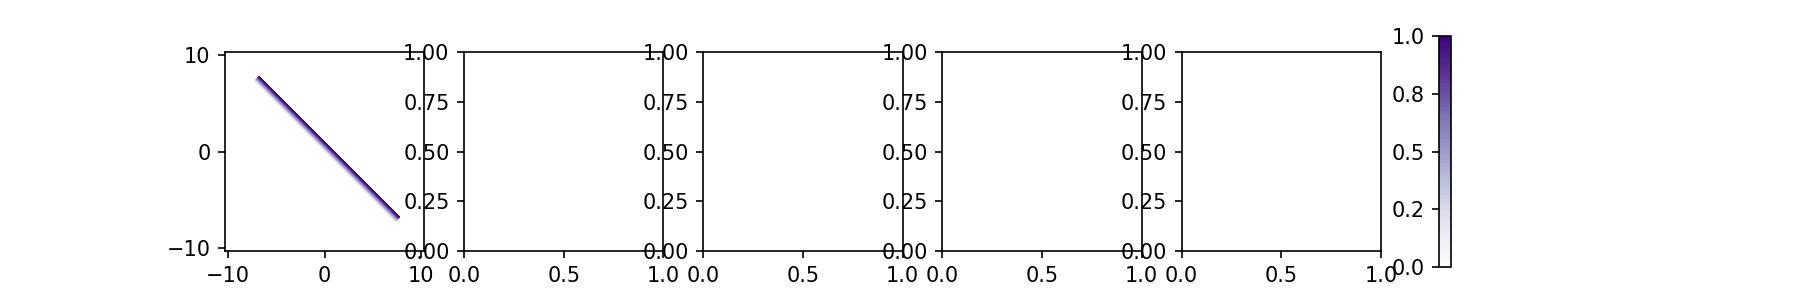

In [285]:
fig, ax = plt.subplots(1,6,figsize=(12, 2), dpi=150)
for s in range(6):
    ax[s].set_aspect('equal', adjustable='box')
    ax[s].set_box_aspect(1)
fig.delaxes(ax[5])

R=1.2*Q_c
LIM = 1
q = np.linspace(0, R, 500)
phiq = np.linspace(0, 2*np.pi, 500)
sigma = 1

#計算2D資料
q, phiq = np.meshgrid(q, phiq)
x, y = q*np.cos(phiq), q*np.sin(phiq)
# fig.colorbar(ax[0].contourf(x, y, (x+y), levels=np.linspace(0,LIM,100), cmap='Purples'), ax=ax[5], format="{x:.1f}", ticks=np.linspace(0,LIM, 5), location='left')
fig.colorbar(ax[0].contourf(x, y, (x+y), levels=np.linspace(0,LIM,100), cmap='Blues'), ax=ax[5], format="{x:.1f}", ticks=np.linspace(0,LIM, 5), location='left')
for s in range(5):
    l = s-2
    print(s)
    # ax[s].contourf(x, y, A(phiq,q,l), levels=np.linspace(0,LIM,100), cmap='Purples')
    ax[s].contourf(x, y, A(phiq,q,l,sigma), levels=np.linspace(0,LIM,100), cmap='Blues')
    ax[s].add_line(Line2D(np.linspace(-3.5, -3.5+0.86, 50),np.linspace(-3.5, -3.5, 50) ,linewidth=1, linestyle='-', color='black'))
    ax[s].set_xticks(np.arange(-4, 6, 2))
    ax[s].set_yticks(np.arange(-4, 6, 2))
    ax[s].set_xlim(-4, 4)
    ax[s].set_ylim(-4, 4)
    ax[s].set_xticks([])
    ax[s].set_yticks([])
    
    
# ax[0].set_xlabel('q$_{x}$')
# ax[0].set_ylabel('q$_{y}$',rotation=0)
# ax[0].annotate("0.1 Q$_c$", xy=(0.05, 0.1),xycoords=ax[0])
plt.tight_layout()
plt.show()    

In [278]:
def uanalytic(phiq,q,l,sigma):
    uanalytic = -1/np.sqrt(2) * (q/np.sqrt(q**2+q_0**2)) * (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) * np.exp(complex(0,1)*(sigma+l)*phiq)
    return uanalytic

def A(phiq,q,l,sigma):
    A = np.real(uanalytic(phiq,q,l,sigma)*3.262)
    return A

0
1
2
3
4


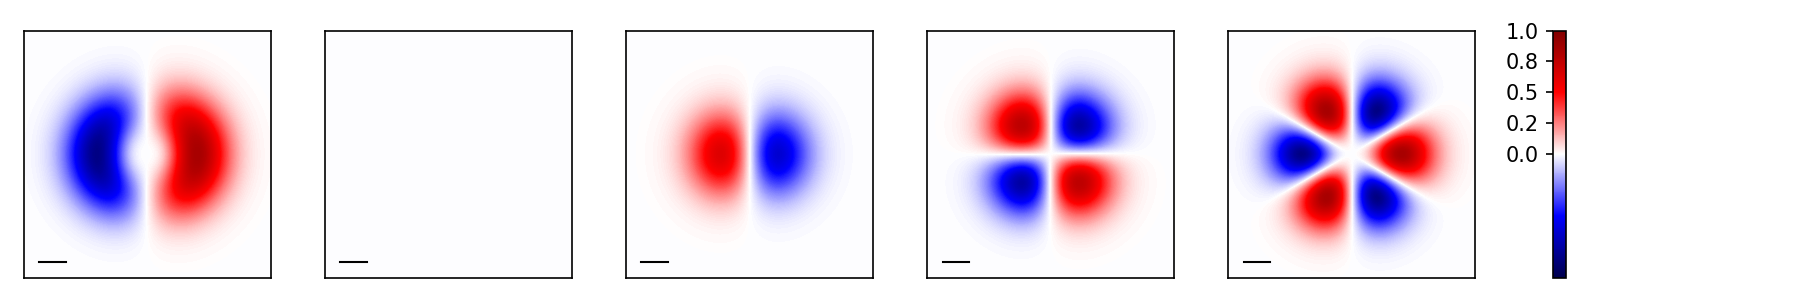

In [280]:
fig, ax = plt.subplots(1,6,figsize=(12, 2), dpi=150)
for s in range(6):
    ax[s].set_aspect('equal', adjustable='box')
    ax[s].set_box_aspect(1)
fig.delaxes(ax[5])

R=1.2*Q_c
LIM = 1
q = np.linspace(0, R, 500)
phiq = np.linspace(0, 2*np.pi, 500)
sigma = +1

#計算2D資料
q, phiq = np.meshgrid(q, phiq)
x, y = q*np.cos(phiq), q*np.sin(phiq)
fig.colorbar(ax[0].contourf(x, y, (x+y), levels=np.linspace(-LIM,LIM,500), cmap='seismic'), ax=ax[5], format="{x:.1f}", ticks=np.linspace(0,LIM, 5), location='left')

for s in range(5):
    l = s-2
    print(s)
    ax[s].contourf(x, y, A(phiq,q,l,sigma), levels=np.linspace(-LIM,LIM,500), cmap='seismic')
    ax[s].add_line(Line2D(np.linspace(-3.5, -3.5+0.86, 50),np.linspace(-3.5, -3.5, 50) ,linewidth=1, linestyle='-', color='black'))
    ax[s].set_xticks(np.arange(-4, 6, 2))
    ax[s].set_yticks(np.arange(-4, 6, 2))
    ax[s].set_xlim(-4, 4)
    ax[s].set_ylim(-4, 4)
    ax[s].set_xticks([])
    ax[s].set_yticks([])
    
    
# ax[0].set_xlabel('q$_{x}$')
# ax[0].set_ylabel('q$_{y}$',rotation=0)
# ax[0].annotate("0.1 Q$_c$", xy=(0.05, 0.1),xycoords=ax[0])
plt.tight_layout()
plt.show()  

In [267]:
W = 1.5 #um(10**-6m)

def Factorial(n):
    f=1
    for i in range(1,n+1,1):
        f*=i 
    return f

def Laguerre(rho,l,p):
    l = np.abs(l)
    L = 0
    for m in range(p+1):
        L += (-1)**m * Factorial(l+p) / (Factorial(p-m)*Factorial(l+m)*Factorial(m)) * (2*(rho/W)**2)**m
    return L

def f(rho,l,p):
    l = np.abs(l)
    f = np.sqrt((Factorial(p)*2)/(np.pi*Factorial(l+p))) * np.exp(-(rho/W)**2) * (np.sqrt(2)*rho/W)**l * Laguerre(rho,l,p)
    return f 
    
def u(phi,rho,l,p):
    u = f(rho,l,p) * np.exp(complex(0,1)*l*phi)
    return u

def uz(phi,rho,sigma,l,p):
    uz = complex(0,1) * (1 / (np.sqrt(2)*q*rho)) * ( (np.abs(l)-sigma*l) - (2*rho**2/(W**2)) ) * f(rho,l,p) * np.exp(complex(0,1)*(sigma+l)*phi)
    return uz

def ux(phi,rho,l1,l2,p,beta,alpha):
    ux = (1*np.cos(beta/2)*u(phi,rho,l1,p) +1*np.exp(complex(0,1)*alpha)*np.sin(beta/2)*u(phi,rho,l2,p) )/np.sqrt(2)
    return ux

def uy(phi,rho,sigma1,sigma2,l1,l2,p,beta,alpha):
    uy = complex(0,1)*( sigma1*np.cos(beta/2)*u(phi,rho,l1,p)  +sigma2*np.exp(complex(0,1)*alpha)*np.sin(beta/2)*u(phi,rho,l2,p) )/np.sqrt(2)  
    return uy

0
1
2
3
4
5


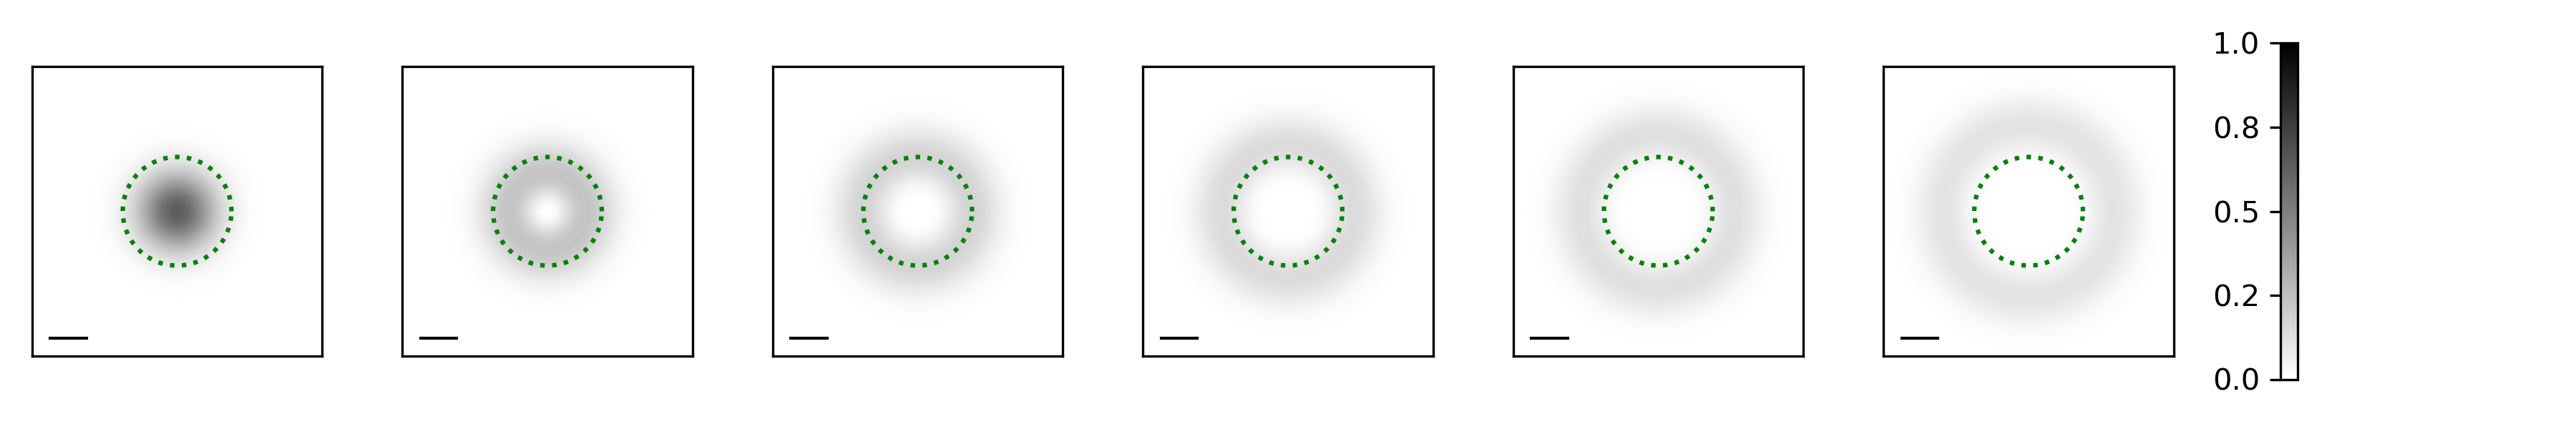

In [110]:
fig, ax = plt.subplots(1,7,figsize=(12, 2), dpi=300)
for s in range(7):
    ax[s].set_aspect('equal', adjustable='box')
    ax[s].set_box_aspect(1)
fig.delaxes(ax[6])

t = np.arange(0, 2*np.pi, 0.02)
LIM = 1
#計算2D資料
rho = np.linspace(0, 4*W, 200)
phi = np.linspace(0, 2*np.pi, 200)
rho, phi = np.meshgrid(rho, phi)
X, Y = rho*np.cos(phi), rho*np.sin(phi)
fig.colorbar(ax[0].contourf(X, Y, (X+Y), levels=np.linspace(0,LIM,500), cmap='gist_yarg'), ax=ax[6], format="{x:.1f}", ticks=np.linspace(0,LIM, 5), location='left')

for s in range(6):
    l = s
    p = 0
    print(s)
    ax[s].contourf(X, Y, np.abs(u(phi,rho,l,p))**2 , levels=np.linspace(0,LIM,500), cmap='gist_yarg')
    ax[s].add_line(Line2D(np.linspace(-3.5, -2.5),np.linspace(-3.5, -3.5, 50) ,linewidth=1, linestyle='-', color='black'))
    ax[s].plot(W*np.cos(t),W*np.sin(t),linestyle=':',color="green",label='beam waist W=1.5 um') 
    ax[s].set_xticks(np.arange(-4, 6, 2), [' ', ' ', ' ', ' ', ' '])
    ax[s].set_yticks(np.arange(-4, 6, 2), [' ', ' ', ' ', ' ', ' '])
    ax[s].set_xlim(-4, 4)
    ax[s].set_ylim(-4, 4)
    # ax[s].grid(True, zorder=0)
    ax[s].set_xticks([])
    ax[s].set_yticks([])
    
# plt.subplots_adjust(right=0.88)

# cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
# fig.colorbar(mappable, cax=cax,
#              format="{x:.1f}",
#              ticks=np.linspace(0,LIM,5))

# ax[0].legend()
# ax[0].set_xlabel('$_{x}$')
# ax[0].set_ylabel('$_{y}$',rotation=0)
# ax[0].annotate("0.1 $$", xy=(0.05, 0.1),xycoords=ax[0])
plt.tight_layout()
plt.show()    

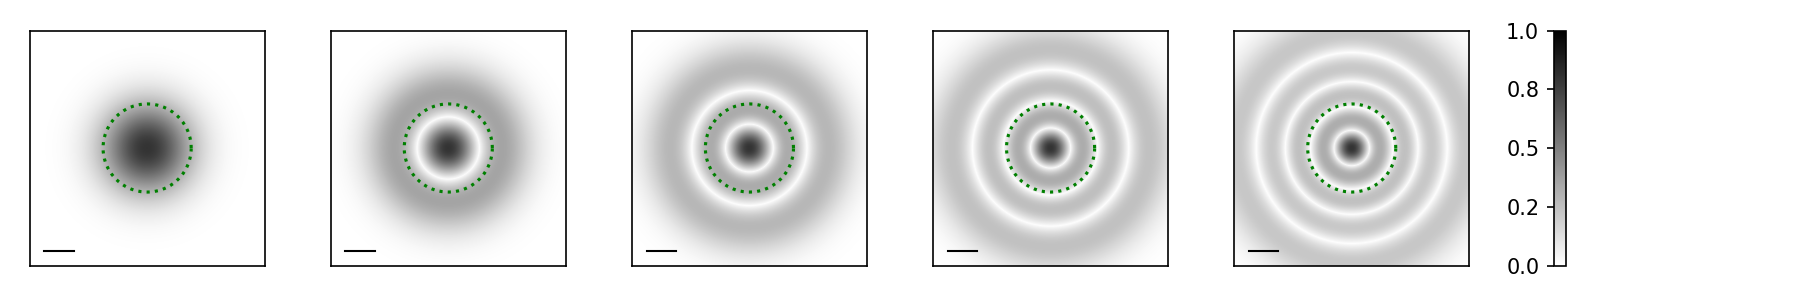

In [301]:
W = 1.5
LIM = 1

fig, ax = plt.subplots(1,6,figsize=(12, 2), dpi=150)

for s in range(6):
    ax[s].set_aspect('equal', adjustable='box')
    ax[s].set_box_aspect(1)

fig.delaxes(ax[5])

# ----------------------------
# Cartesian 網格（保持你原本版型）
# ----------------------------
x = np.linspace(-4, 4, 400)
y = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x, y)

# 計算 polar 變數
rho = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

# ----------------------------
# colorbar dummy（結構完全不動）
# ----------------------------
cbar_plot = ax[0].contourf(
    X, Y,
    np.abs(u(phi, rho, 0, 0)),   # ← 只換這裡
    levels=np.linspace(0, LIM, 500),
    cmap='gist_yarg'
)

fig.colorbar(
    cbar_plot,
    ax=ax[5],
    format="{x:.1f}",
    ticks=np.linspace(0, LIM, 5),
    location='left'
)

t = np.linspace(0, 2*np.pi, 400)

# ----------------------------
# 主迴圈（版型完全照你給的）
# ----------------------------
for s in range(6):
    # l = int(s)-2
    l=0
    p = int(s)

    Z = np.abs(u(phi, rho, l, p))   # ← 只換成你的函式

    ax[s].contourf(
        X, Y,
        Z,
        levels=np.linspace(0, LIM, 500),
        cmap='gist_yarg'
    )

    ax[s].add_line(
        Line2D(np.linspace(-3.5, -2.5),
               np.linspace(-3.5, -3.5),
               linewidth=1,
               linestyle='-',
               color='black')
    )

    ax[s].plot(
        W*np.cos(t),
        W*np.sin(t),
        linestyle=':',
        color="green"
    )

    ax[s].set_xlim(-4, 4)
    ax[s].set_ylim(-4, 4)
    ax[s].set_xticks([])
    ax[s].set_yticks([])

plt.tight_layout()
plt.show()

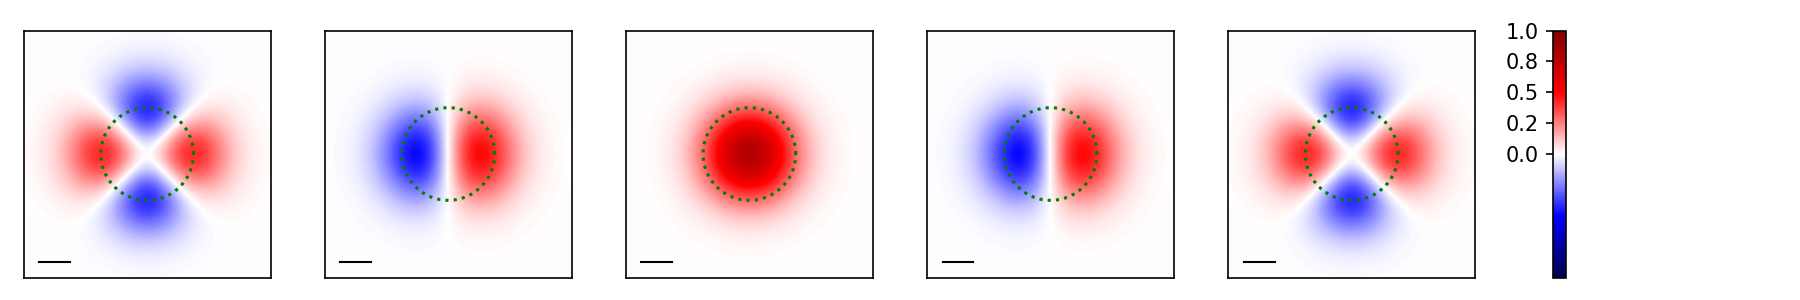

In [259]:
W = 1.5
LIM = 1

fig, ax = plt.subplots(1,6,figsize=(12, 2), dpi=150)

for s in range(6):
    ax[s].set_aspect('equal', adjustable='box')
    ax[s].set_box_aspect(1)

fig.delaxes(ax[5])

# ----------------------------
# Cartesian 網格（保持你原本版型）
# ----------------------------
x = np.linspace(-4, 4, 400)
y = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x, y)

# 計算 polar 變數
rho = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

# ----------------------------
# colorbar dummy（結構完全不動）
# ----------------------------
cbar_plot = ax[0].contourf(
    X, Y,
    np.real(u(phi, rho, 0, 0)),   # ← 只換這裡
    levels=np.linspace(-LIM, LIM, 500),
    cmap='seismic'
)

fig.colorbar(
    cbar_plot,
    ax=ax[5],
    format="{x:.1f}",
    ticks=np.linspace(0, LIM, 5),
    location='left'
)

t = np.linspace(0, 2*np.pi, 400)

# ----------------------------
# 主迴圈（版型完全照你給的）
# ----------------------------
for s in range(5):
    l = int(s)-2
    # p = int(s)

    Z = np.real(u(phi, rho, l, 0))   # ← 只換成你的函式

    ax[s].contourf(
        X, Y,
        Z,
        levels=np.linspace(-LIM, LIM, 500),
        cmap='seismic'
    )

    ax[s].add_line(
        Line2D(np.linspace(-3.5, -2.5),
               np.linspace(-3.5, -3.5),
               linewidth=1,
               linestyle='-',
               color='black')
    )

    ax[s].plot(
        W*np.cos(t),
        W*np.sin(t),
        linestyle=':',
        color="green"
    )

    ax[s].set_xlim(-4, 4)
    ax[s].set_ylim(-4, 4)
    ax[s].set_xticks([])
    ax[s].set_yticks([])

plt.tight_layout()
plt.show()

In [261]:
W = 1.5 #um(10**-6m)
# W = 0.632

def Factorial(n):
    f=1
    for i in range(1,n+1,1):
        f*=i 
    return f

def Laguerre(rho,l,p):
    l = np.abs(l)
    L = 0
    for m in range(p+1):
        L += (-1)**m * Factorial(l+p) / (Factorial(p-m)*Factorial(l+m)*Factorial(m)) * (2*(rho/W)**2)**m
    return L

def f(rho,l,p):
    l = np.abs(l)
    f = np.sqrt((Factorial(p)*2)/(np.pi*Factorial(l+p))) * np.exp(-(rho/W)**2) * (np.sqrt(2)*rho/W)**l * Laguerre(rho,l,p)
    return f 
    
def u(phi,rho,l,p):
    u = f(rho,l,p) * np.exp(complex(0,1)*l*phi)
    return u

def uz(phi,rho,sigma,l,p):
    uz = complex(0,1) * (1 / (np.sqrt(2)*q*rho)) * ( np.abs(l)+sigma*l  - 2*rho**2/(W**2) ) * f(rho,l,p) * np.exp(complex(0,1)*(sigma+l)*phi)
    return uz

def ux(phi,rho,l1,l2,p,beta,alpha):
    ux = (1*np.cos(beta/2)*u(phi,rho,l1,p) +1*np.exp(complex(0,1)*alpha)*np.sin(beta/2)*u(phi,rho,l2,p) )/np.sqrt(2)
    return ux

def uy(phi,rho,sigma1,sigma2,l1,l2,p,beta,alpha):
    uy = complex(0,1)*( sigma1*np.cos(beta/2)*u(phi,rho,l1,p)  +sigma2*np.exp(complex(0,1)*alpha)*np.sin(beta/2)*u(phi,rho,l2,p) )/np.sqrt(2)  
    return uy

1/2 * qW^2=1.4763123372132485 um
0.5 0.532
qW=5.905249348852994
Lambda= 532.0 nm


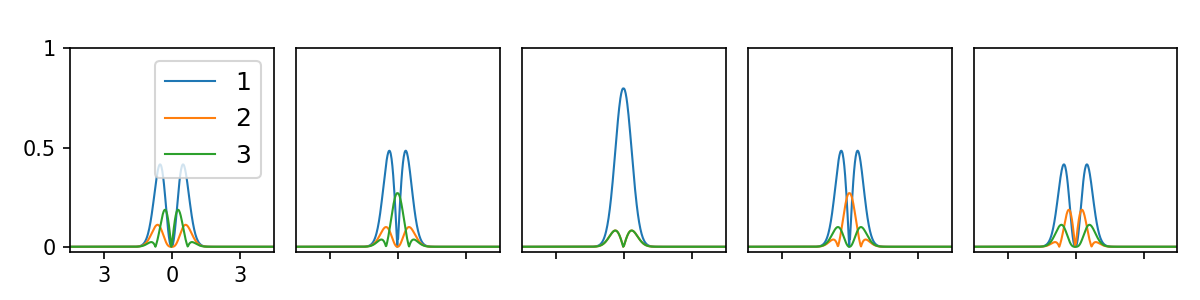

In [262]:
W = 1.5
W = 0.5
Lambda = 0.532 #um
q = 2*np.pi/Lambda
print("1/2 * qW^2="+str(0.5*q*W**2), 'um')
print(W, Lambda)
print("qW="+str(q*W))
print('Lambda=',Lambda*np.power(10,3), 'nm')
LIM = 1

fig, ax = plt.subplots(1,5,figsize=(8, 2), dpi=150)

R = 4.5
N = 250
rho = np.linspace(R/N, R, N)
minusrho = np.linspace(R, -R/N, N)
for s in range(5):
    # ax[s].set_aspect('equal', adjustable='box')
    ax[s].set_box_aspect(1)

# ----------------------------
# 主迴圈（版型完全照你給的）
# ----------------------------
phi = 0
for s in range(5):
    l = int(s-2)

    Z1right = np.abs(u(phi, rho, l, 0))  
    Z2right = np.abs(uz(phi, rho, 1,  l, 0)) 
    Z3right = np.abs(uz(phi, rho, -1, l, 0)) 
    
    Z1left = np.abs(u(phi+np.pi, minusrho, l, 0))  
    Z2left = np.abs(uz(phi+np.pi, minusrho, 1,  l, 0)) 
    Z3left = np.abs(uz(phi+np.pi, minusrho, -1, l, 0)) 
    
    Z1=np.append(Z1left, Z1right)
    Z2=np.append(Z2left, Z2right)
    Z3=np.append(Z3left, Z3right)

    ax[s].plot(np.linspace(-R, R, 2*N), Z1, linewidth=1)
    ax[s].plot(np.linspace(-R, R, 2*N), Z2, linewidth=1)
    ax[s].plot(np.linspace(-R, R, 2*N), Z3, linewidth=1)
    
    ax[s].set_xticks([-3, 0, 3], [" ", " ", " "])
    ax[s].set_yticks([])
    ax[s].set_xlim(-R, R)
    ax[s].set_ylim(-0.025, 1)
    
ax[0].set_yticks([0, 0.5, 1],["0", "0.5", "1"]) 
ax[0].set_xticks([-3, 0, 3], ["3", "0", "3"])
ax[0].legend(["1", "2", "3"],fontsize=12)
plt.tight_layout()
plt.show()
 

In [263]:
R=5
N = 5
rho = np.linspace(R/(N-1), R, N-1)
minusrho = np.linspace(-R, 0, N)
print(np.append(minusrho , rho))

[-5.   -3.75 -2.5  -1.25  0.    1.25  2.5   3.75  5.  ]


1/qW=0.15072508815742935
1/2 * qW^2=2.0965321955555556 um
qW=6.634595555555555
Lambda= 598.5252726991562 nm


C:\Users\nycugpu\AppData\Local\Temp\ipykernel_23428\3529857957.py:27: RuntimeWarning: divide by zero encountered in divide
  uz = complex(0,1) * (1 / (np.sqrt(2)*q*rho)) * ( np.abs(l)+sigma*l  - 2*rho**2/(W**2) ) * f(rho,l,p) * np.exp(complex(0,1)*(sigma+l)*phi)
C:\Users\nycugpu\AppData\Local\Temp\ipykernel_23428\3529857957.py:27: RuntimeWarning: invalid value encountered in multiply
  uz = complex(0,1) * (1 / (np.sqrt(2)*q*rho)) * ( np.abs(l)+sigma*l  - 2*rho**2/(W**2) ) * f(rho,l,p) * np.exp(complex(0,1)*(sigma+l)*phi)


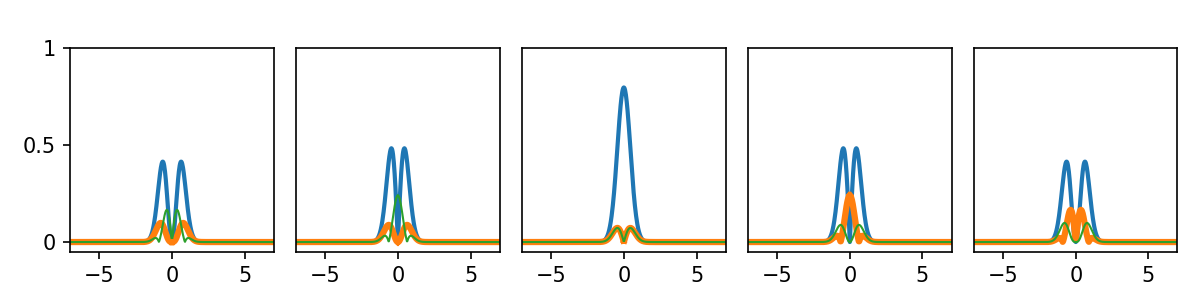

In [264]:
W = 1.5
W = 0.632
q = 10.497777777777777 #um-1
print("1/qW="+str(1/(q*W)) )
LIM = 1
Lambda = 2*np.pi/q
print("1/2 * qW^2="+str(0.5*q*W**2), 'um')
print("qW="+str(q*W))
print('Lambda=',Lambda*np.power(10,3), 'nm')
LIM = 1

fig, ax = plt.subplots(1,5,figsize=(8, 2), dpi=150)

R = 7
N = 250
rho = np.linspace(R/(N-1), R, N-1)
minusrho = np.linspace(R, 0, N)
for s in range(5):
    # ax[s].set_aspect('equal', adjustable='box')
    ax[s].set_box_aspect(1)

# ----------------------------
# 主迴圈（版型完全照你給的）
# ----------------------------
for s in range(5):
    l = int(s-2)

    Z1right = np.abs(u(phi, rho, l, 0))  
    Z2right = np.abs(uz(phi, rho, 1,  l, 0)) 
    Z3right = np.abs(uz(phi, rho, -1, l, 0)) 
    
    Z1left = np.abs(u(phi+np.pi, minusrho, l, 0))  
    Z2left = np.abs(uz(phi+np.pi, minusrho, 1,  l, 0)) 
    Z3left = np.abs(uz(phi+np.pi, minusrho, -1, l, 0)) 
    
    Z1=np.append(Z1left, Z1right)
    Z2=np.append(Z2left, Z2right)
    Z3=np.append(Z3left, Z3right)

    ax[s].plot(np.linspace(-R, R, 2*N-1), Z1, linewidth=2)
    ax[s].plot(np.linspace(-R, R, 2*N-1), Z2, linewidth=3)
    ax[s].plot(np.linspace(-R, R, 2*N-1), Z3, linewidth=1)
#     
    # ax[s].set_xticks([-R, -2/W, 0, 2/W, 4/W], ["4", "2", "0", "2", "4"])
    ax[s].set_yticks([])
    ax[s].set_xlim(-R, R)
    ax[s].set_ylim(-0.05, 1)
    
ax[0].set_yticks([0, 0.5, 1],["0", "0.5", "1"]) 
# ax[0].legend(["1", "2", "3"],fontsize=12)
plt.tight_layout()
plt.show()

1/2 * qW^2=11.809999999999999 um
qW=15.746666666666666
Lambda= 598.5252726991562 nm


C:\Users\nycugpu\AppData\Local\Temp\ipykernel_23428\3529857957.py:27: RuntimeWarning: divide by zero encountered in divide
  uz = complex(0,1) * (1 / (np.sqrt(2)*q*rho)) * ( np.abs(l)+sigma*l  - 2*rho**2/(W**2) ) * f(rho,l,p) * np.exp(complex(0,1)*(sigma+l)*phi)
C:\Users\nycugpu\AppData\Local\Temp\ipykernel_23428\3529857957.py:27: RuntimeWarning: invalid value encountered in multiply
  uz = complex(0,1) * (1 / (np.sqrt(2)*q*rho)) * ( np.abs(l)+sigma*l  - 2*rho**2/(W**2) ) * f(rho,l,p) * np.exp(complex(0,1)*(sigma+l)*phi)


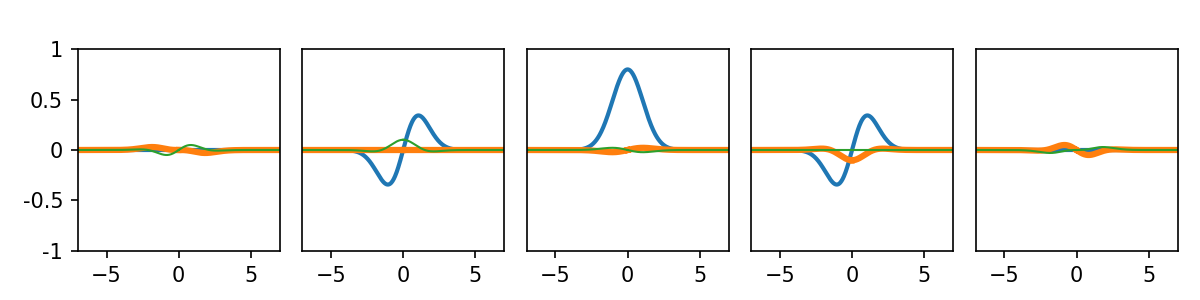

In [265]:
W = 1.5
# W = 0.632
q = 10.497777777777777 #um-1
Lambda = 2*np.pi/q
print("1/2 * qW^2="+str(0.5*q*W**2), 'um')
print("qW="+str(q*W))
print('Lambda=',Lambda*np.power(10,3), 'nm')
LIM = 1

fig, ax = plt.subplots(1,5,figsize=(8, 2), dpi=150)

R = 7
N = 250
rho = np.linspace(R/(N-1), R, N-1)
minusrho = np.linspace(R, 0, N)
for s in range(5):
    # ax[s].set_aspect('equal', adjustable='box')
    ax[s].set_box_aspect(1)

# ----------------------------
# 主迴圈（版型完全照你給的）
# ----------------------------
phi = np.pi/4
for s in range(5):
    l = int(s-2)

    Z1right = np.real(u(phi, rho, l, 0))  
    Z2right = np.real(uz(phi, rho, 1,  l, 0)) 
    Z3right = np.real(uz(phi, rho, -1, l, 0)) 
    
    Z1left = np.real(u(phi+np.pi, minusrho, l, 0))  
    Z2left = np.real(uz(phi+np.pi, minusrho, 1,  l, 0)) 
    Z3left = np.real(uz(phi+np.pi, minusrho, -1, l, 0)) 
    
    Z1=np.append(Z1left, Z1right)
    Z2=np.append(Z2left, Z2right)
    Z3=np.append(Z3left, Z3right)

    ax[s].plot(np.linspace(-R, R, 2*N-1), Z1, linewidth=2)
    ax[s].plot(np.linspace(-R, R, 2*N-1), Z2, linewidth=3)
    ax[s].plot(np.linspace(-R, R, 2*N-1), Z3, linewidth=1)
#     
    # ax[s].set_xticks([-R, -2/W, 0, 2/W, 4/W], ["4", "2", "0", "2", "4"])
    ax[s].set_yticks([])
    ax[s].set_xlim(-R, R)
    ax[s].set_ylim(-1, 1)
    
ax[0].set_yticks([-1, -0.5, 0, 0.5, 1],["-1", "-0.5", "0", "0.5", "1"]) 
# ax[0].legend(["1", "2", "3"],fontsize=12)
plt.tight_layout()
plt.show()

In [426]:
def VVBux(phi,rho,l1,l2,p,beta,alpha):
    ux = (1*np.cos(beta/2)*u(phi,rho,l1,p) +1*np.exp(complex(0,1)*alpha)*np.sin(beta/2)*u(phi,rho,l2,p) )/np.sqrt(2)
    return ux

def VVBuy(phi,rho,sigma1,sigma2,l1,l2,p,beta,alpha):
    uy = complex(0,1)*( sigma1*np.cos(beta/2)*u(phi,rho,l1,p)  +sigma2*np.exp(complex(0,1)*alpha)*np.sin(beta/2)*u(phi,rho,l2,p) )/np.sqrt(2)  
    return uy

def uintensity(phi,rho,sigma1,sigma2,l1,l2,p,beta,alpha):
    uin = np.sqrt( np.abs(VVBux(phi,rho,l1,l2,p,beta,alpha))**2 + np.abs(VVBuy(phi,rho,sigma1,sigma2,l1,l2,p,beta,alpha))**2 )
    return uin

def uz(phi,rho,sigma,l,p):
    uz = complex(0,1) * (1 / (np.sqrt(2)*q*rho)) * ( np.abs(l)+sigma*l  - 2*rho**2/(W**2) ) * f(rho,l,p) * np.exp(complex(0,1)*(sigma+l)*phi)
    return uz

def VVBuz(phi,rho,sigma1,sigma2,l1,l2,p,beta,alpha):
    VVBuz = np.cos(beta/2)*uz(phi,rho,sigma1,l1,p)+np.exp(complex(0,1)*alpha)*np.sin(beta/2)*uz(phi,rho,sigma2,l2,p)
    VVBuz = np.abs(VVBuz)
    return VVBuz

Output()

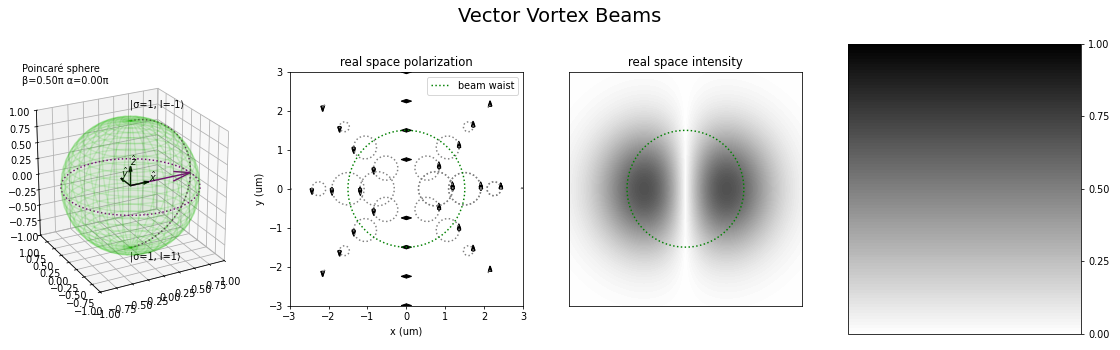

In [427]:
# -------------------------------------------------------
# Constants
# -------------------------------------------------------
W = 1.5
w = 1

sigma1 = 1
sigma2 = 1

t = np.arange(0, 2*np.pi, 0.02)

# -------------------------------------------------------
# Mesh for intensity map
# -------------------------------------------------------
rho = np.linspace(0.001, 4*W, 200)
phi = np.linspace(0, 2*np.pi, 200)
rho, phi = np.meshgrid(rho, phi)

X = rho*np.cos(phi)
Y = rho*np.sin(phi)

# -------------------------------------------------------
# Sphere mesh
# -------------------------------------------------------
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx = np.cos(U)*np.sin(V)
sy = np.sin(U)*np.sin(V)
sz = np.cos(V)

circle = np.linspace(0, 2*np.pi, 100)
polar = np.linspace(0, np.pi, 100)

# -------------------------------------------------------
# Figure Layout
# -------------------------------------------------------
fig = plt.figure(figsize=(16,5), dpi=70)

ax3D   = fig.add_subplot(1,4,1, projection='3d')
ax_pol = fig.add_subplot(1,4,2)
ax_int = fig.add_subplot(1,4,3)
cax    = fig.add_subplot(1,4,4)

ax3D.set_aspect('equal')
ax_pol.set_aspect('equal')
ax_int.set_aspect('equal')

# -------------------------------------------------------
# Widgets
# -------------------------------------------------------
beta_slider = widgets.FloatSlider(
    value=0.5,min=0,max=1,step=0.02,
    description='beta (π)'
)

alpha_slider = widgets.FloatSlider(
    value=0,min=0,max=2,step=0.02,
    description='alpha (π)'
)

l1_box = widgets.IntText(value=-1, description='l')
l2_box = widgets.IntText(value=1, description="l'")
p_box  = widgets.IntText(value=0, description='p')

# -------------------------------------------------------
# Main Plot Function
# -------------------------------------------------------
def update_plot(l1,l2,p,beta,alpha):

    beta  *= np.pi
    alpha *= np.pi

    ax3D.cla()
    ax_pol.cla()
    ax_int.cla()
    cax.cla()

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(
        sx, sy, sz,
        color=(0.15,0.8,0.05,0.15)
    )

    ax3D.plot_surface(
        sx, sy, sz,
        color=(0.15,0.8,0.05,0.05)
    )

    qx = np.cos(alpha)*np.sin(beta)
    qy = np.sin(alpha)*np.sin(beta)
    qz = np.cos(beta)

    ax3D.quiver(0,0,0,qx,qy,qz,color='purple')

    ax3D.quiver(0,0,0,0.3,0,0,color='k')
    ax3D.quiver(0,0,0,0,0.3,0,color='k')
    ax3D.quiver(0,0,0,0,0,0.3,color='k')

    # guide circles
    ax3D.plot(
        np.sin(beta)*np.cos(circle),
        np.sin(beta)*np.sin(circle),
        np.cos(beta)+0*circle,
        linestyle='dotted',
        color='purple'
    )

    ax3D.plot(
        np.sin(polar)*np.cos(alpha),
        np.sin(polar)*np.sin(alpha),
        np.cos(polar),
        linestyle='dotted',
        color='purple'
    )

    ax3D.text2D(
        0.05,0.95,
        f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π',
        transform=ax3D.transAxes
    )

    ax3D.text(0.3,0,0,r'$\hat{x}$')
    ax3D.text(0,0.3,0,r'$\hat{y}$')
    ax3D.text(0,0,0.3,r'$\hat{z}$')

    ax3D.text(0,0,1.2,f'|σ={sigma1}, l={l1}⟩')
    ax3D.text(0,0,-1.2,f'|σ={sigma2}, l={l2}⟩')

    ax3D.set_xlim(-1,1)
    ax3D.set_ylim(-1,1)
    ax3D.set_zlim(-1,1)

    ax3D.view_init(24,-118)

    # ===================================================
    # 2. Real-space polarization
    # ===================================================
    for ang in np.linspace(0,2*np.pi,9):
        for R in np.linspace(W/2,2*W,4):

            x = R*np.cos(ang)
            y = R*np.sin(ang)

            a = ux(ang,R,l1,l2,p,beta,alpha)
            b = uy(ang,R,sigma1,sigma2,l1,l2,p,beta,alpha)

            traj_x = x + a*np.exp(-1j*w*t)
            traj_y = y + b*np.exp(-1j*w*t)

            ax_pol.plot(
                np.real(traj_x),
                np.real(traj_y),
                linestyle=':',
                color='gray'
            )

            # -------------------------
            # restored arrows
            # -------------------------
            ax_pol.arrow(
                np.real(traj_x[-5]),
                np.real(traj_y[-5]),
                np.real(traj_x[-1]-traj_x[-5]),
                np.real(traj_y[-1]-traj_y[-5]),
                width=0.03,
                color='k'
            )

            ax_pol.arrow(
                np.real(traj_x[0]),
                np.real(traj_y[0]),
                np.real(traj_x[5]-traj_x[0]),
                np.real(traj_y[5]-traj_y[0]),
                width=0.03,
                color='k'
            )

    ax_pol.plot(W*np.cos(t),W*np.sin(t),'g:',label='beam waist')

    ax_pol.set_title("real space polarization")
    ax_pol.set_xlabel("x (um)")
    ax_pol.set_ylabel("y (um)")
    ax_pol.set_xlim(-2*W,2*W)
    ax_pol.set_ylim(-2*W,2*W)
    ax_pol.legend()

    # ===================================================
    # 3. Intensity
    # ===================================================
    I = uintensity(phi,rho,sigma1,sigma2,l1,l2,p,beta,alpha)

    contour = ax_int.contourf(
        X,Y,I,
        levels=np.linspace(0,1,100),
        cmap='gist_yarg'
    )

    ax_int.plot(W*np.cos(t),W*np.sin(t),'g:')

    ax_int.set_title("real space intensity")
    ax_int.set_xticks([])
    ax_int.set_yticks([])
    ax_int.set_xlim(-2*W,2*W)
    ax_int.set_ylim(-2*W,2*W)

    # -------------------------
    # restored colorbar
    # -------------------------
    plt.colorbar(
        contour,
        cax=cax,
        ticks=np.linspace(0,1,5)
    )

    print(
        f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π'
    )

# -------------------------------------------------------
# UI
# -------------------------------------------------------
out = widgets.interactive_output(
    update_plot,
    {
        'l1':l1_box,
        'l2':l2_box,
        'p':p_box,
        'beta':beta_slider,
        'alpha':alpha_slider
    }
)

ui = widgets.VBox([
    widgets.Label("coefficient"),
    widgets.HBox([l1_box,l2_box,p_box]),
    widgets.Label("parameter"),
    widgets.HBox([beta_slider,alpha_slider])
])

plt.suptitle("Vector Vortex Beams", fontsize=20)
plt.tight_layout()

display(ui,out)

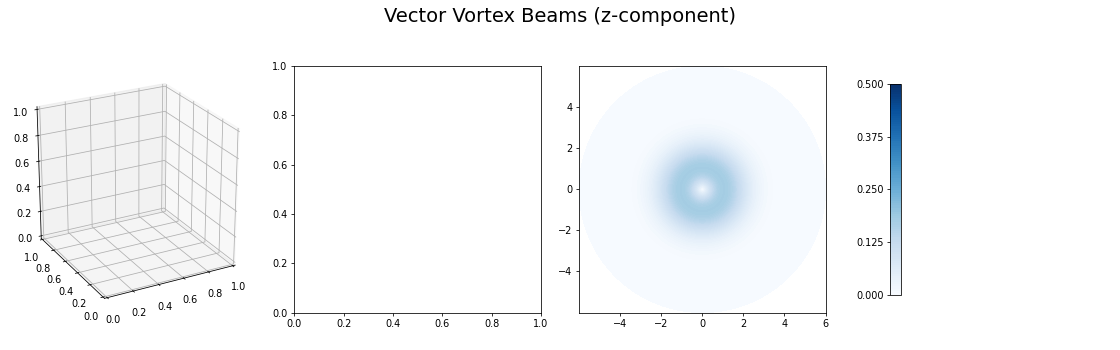

Output()

In [428]:
fig, ax = plt.subplots(1,4,figsize=(16,5), dpi=70)
ax3D = fig.add_subplot(1, 4, 1, projection='3d')
fig.delaxes(ax[0])
fig.delaxes(ax[3])

beta = widgets.FloatSlider(value=1/2, min=0., max=1, step=1/50 ,description='beta (pi)')
alpha = widgets.FloatSlider(value=0, min=0., max=2, step=1/50 ,description='alpha (pi)')
t = np.arange(0, 2*np.pi, 0.02)
rho = np.linspace(0.001, 4*W, 200)
phi = np.linspace(0, 2*np.pi, 200)
rho, phi = np.meshgrid(rho, phi)
X, Y = rho*np.cos(phi), rho*np.sin(phi)
l1 = widgets.IntText(value=-1, min=0, max=10, step=1, description='l:', disabled=False)
l2 = widgets.IntText(value=1, min=0, max=10, step=1, description='l\':', disabled=False)
p = widgets.IntText(value=0, min=0, max=10, step=1, description='p:', disabled=False)
sigma1 = 1
sigma2 = -1

ax3D.set_aspect('equal', adjustable='box')
ax[1].set_aspect('equal', adjustable='box')
ax[2].set_aspect('equal', adjustable='box')

U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
wx = np.cos(U) * np.sin(V)
wy = np.sin(U) * np.sin(V)
wz = np.cos(V)

o = np.linspace(0,2*np.pi,30, endpoint=True)
c = np.linspace(0, np.pi,15, endpoint=True)

def need(l1,l2,p,beta,alpha):
    beta = beta*np.pi
    alpha = alpha*np.pi
    ax3D.cla()
    ax[1].cla()
    ax[2].cla()

    ax3D.plot_wireframe(wx, wy, wz, rcount=16, ccount=13, color=[0.154, 0.8059, 0.0394,0.15])
    ax3D.plot_surface(wx, wy, wz, rcount=16, ccount=13, color=[0.154, 0.8059, 0.0394,0.05])
    
    qx =1*np.cos(alpha) * np.sin(beta)
    qy =1*np.sin(alpha) * np.sin(beta)
    qz =1*np.cos(beta)
    ax3D.quiver(0, 0, 0, qx, qy, qz, color=[0.547, 0.152, 0.996])
    ax3D.quiver(0, 0, 0, 0.3, 0, 0, color='k')
    ax3D.quiver(0, 0, 0, 0, 0.3, 0, color='k')
    ax3D.quiver(0, 0, 0, 0, 0, 0.3, color='k')

    ax3D.plot(np.sin(beta)*np.cos(o), np.sin(beta)*np.sin(o), np.cos(beta)+(o*0) , linestyle='dotted', color=[0.547, 0.152, 0.996, 0.8])
    ax3D.plot(np.sin(c)*np.cos(alpha), np.sin(c)*np.sin(alpha), np.cos(c) , linestyle='dotted', color=[0.547, 0.152, 0.996, 0.8])
    

    for i in np.linspace(0, 2*np.pi, 9, endpoint=True):
        for R in np.linspace(W/2, 2*W, 4 ,endpoint=True):
            x = R*np.cos(i)
            y = R*np.sin(i)
            a = ux(i,R,l1,l2,p,beta,alpha) 
            b = uy(i,R,sigma1,sigma2,l1,l2,p,beta,alpha) 
            # ax[1].plot(x+a* np.exp(-complex(0,1)*w*t),y+b* np.exp(-complex(0,1)*w*t),linestyle=':',color="gray") 
            # ax[1].arrow(float(np.real(x+a * np.exp(-complex(0,1)*w*t[-5]))) , float(np.real(y+b * np.exp(-complex(0,1)*w*t[-5]))) ,
            #             float(np.real(a * (np.exp(-complex(0,1)*w*(t[-1]))-np.exp(-complex(0,1)*w*t[-5])))) , float(np.real(b * (np.exp(-complex(0,1)*w*(t[-1]))-np.exp(-complex(0,1)*w*t[-5]))))  ,
            #             width=0.03,color="k" )  
            # ax[1].arrow(float(np.real(x+a * np.exp(-complex(0,1)*w*t[0]))) , float(np.real(y+b * np.exp(-complex(0,1)*w*t[0]))) ,
            #             float(np.real(a * (np.exp(-complex(0,1)*w*(t[5]))-np.exp(-complex(0,1)*w*t[0])))) , float(np.real(b * (np.exp(-complex(0,1)*w*(t[5]))-np.exp(-complex(0,1)*w*t[0]))))  ,
            #             width=0.03,color="k" )

    ax[1].plot(W*np.cos(t),W*np.sin(t),linestyle=':',color="green",label='beam waist W=1.5 um') 
    print('alpha=',format(alpha/np.pi,'.3f'),'𝜋 beta=',format(beta/np.pi,'.3f'),'𝜋' )

    # ax[2].contourf(X, Y, uintensity(phi,rho,sigma1,sigma2,l1,l2,p,beta,alpha), levels=np.linspace(0,1,100), cmap='gist_yarg' )
    # ax[2].plot(W*np.cos(t),W*np.sin(t),linestyle=':',color="green",label='beam waist W=1.5 um') 
    
    Z = get_output(
        phi,rho,sigma1,sigma2,
        l1,l2,p,beta,alpha
    )

    cf = ax[2].contourf(
        X,Y,Z,
        levels=np.linspace(0,0.5,100),
        cmap='Blues'
    )
    # ax[2].contourf(X, Y, VVBuz(phi,rho,sigma1,sigma2,l1,l2,p,beta,alpha), levels=np.linspace(0,0.01,100), cmap='gist_yarg' )
    ax[2].plot(W*np.cos(t),W*np.sin(t),linestyle=':',color="green",label='beam waist W=1.5 um') 

    
    ax3D.text2D(0.05, 0.95, 'Poincaré sphere \nbeta='+str(format(beta/np.pi,'.2f'))+'$\pi$ alpha='+str(format(alpha/np.pi,'.2f'))+'$\pi$', transform=ax3D.transAxes)
    ax3D.text(0.3, 0, 0, "$\hat{x}$", color='k')
    ax3D.text(0, 0.3, 0, "$\hat{y}$", color='k')
    ax3D.text(0, 0, 0.3, "$\hat{z}$", color='k')
    ax3D.text(0, 0, 1.2, "|$\sigma\,="+str(sigma1)+",\,l\,$⟩", color='k',fontsize=9)
    ax3D.text(0, 0, -1.3, "|$\sigma^{'}\,="+str(sigma2)+",\,l^{'}\,$⟩", color='k',fontsize=9)
    ax3D.set_xlabel('x')
    ax3D.set_ylabel('y')
    ax3D.set_zlabel('z')
    ax3D.set_xlim(-1,1)
    ax3D.set_ylim(-1,1)
    ax3D.set_zlim(-1,1)
    x_major_locator=MultipleLocator(0.5)
    y_major_locator=MultipleLocator(0.5)
    z_major_locator=MultipleLocator(0.5)
    ax3D.xaxis.set_major_locator(x_major_locator)
    ax3D.yaxis.set_major_locator(y_major_locator)
    ax3D.zaxis.set_major_locator(z_major_locator)
    ax[1].legend()
    ax[1].set_title('real space polarization')
    ax[1].set_xlabel('x (um)')
    ax[1].set_ylabel('y (um)')
    ax[1].set_xlim(-2*W,2*W)
    ax[1].set_ylim(-2*W,2*W)
    # ax[2].set_title('real space intensity')
    # ax[2].set_xlabel('x (um)')
    # ax[2].set_ylabel('y (um)')
    ax[2].set_xticks([])
    ax[2].set_yticks([])
    ax[2].set_xlim(-2*W,2*W)
    ax[2].set_ylim(-2*W,2*W)


plt.suptitle('Vector Vortex Beams (z-component)' ,fontsize=20)
ax3D.view_init(24, -118, 0)                 #ax.view_init(elev, azim, roll)
plt.colorbar(ax[2].contourf(X, Y, VVBuz(phi,rho,1,-1,-1,1,0,0,0), levels=np.linspace(0,0.5,100), cmap='Blues'),  ax=ax[3], ticks=np.linspace(0,0.5, 5), shrink=0.7, location='left')    
plt.tight_layout(pad=1)
plt.show()

out = widgets.interactive_output(need, {'l1':l1,'l2':l2, 'p':p, 'beta':beta, 'alpha':alpha})
ui = widgets.VBox([widgets.Label('coefficient:'), widgets.HBox([l1,l2,p]), widgets.Label('parameter:'), widgets.HBox([beta,alpha]) ])
display(ui , out )



# C:\Users\USER\Documents\大二資料\code              #存檔位置
# ffmpeg –r 20 –i direction_%01d.png direction.avi  #輸出指令

In [68]:
Lambda = 0.532 #um
q_0 = 2*np.pi/Lambda # um-1
w = c*q_0*10**(-6)
W = 1.5 #um
ZR = 1/2 * q_0 * (W**2) # um-1
Qc = 8.6 #um-1
print(q_0, w, ZR)

def F(phiq,q,l):
    F = (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) 
    return F

def VVBux(phiq,q,l1,l2,beta,alpha):
    ux = (np.cos(beta/2)*F(phiq,q,l1)*np.exp(complex(0,1)*l1*phiq) +np.exp(complex(0,1)*alpha)*np.sin(beta/2)*F(phiq,q,l2)*np.exp(complex(0,1)*l2*phiq) )/np.sqrt(2)
    return ux

def VVBuy(phiq,q,sigma1,sigma2,l1,l2,beta,alpha):
    uy = complex(0,1)*( sigma1*np.cos(beta/2)*F(phiq,q,l1)*np.exp(complex(0,1)*l1*phiq)  +sigma2*np.exp(complex(0,1)*alpha)*np.sin(beta/2)*F(phiq,q,l2)*np.exp(complex(0,1)*l2*phiq) )/np.sqrt(2)  
    return uy

def VVBsity(phiq,q,sigma1,sigma2,l1,l2,beta,alpha):
    uin = np.sqrt( np.abs(VVBux(phiq,q,l1,l2,beta,alpha))**2 + np.abs(VVBuy(phiq,q,sigma1,sigma2,l1,l2,beta,alpha))**2 )
    return uin


11.810498697705988 3540.698434791077 13.286811034919236


Output()

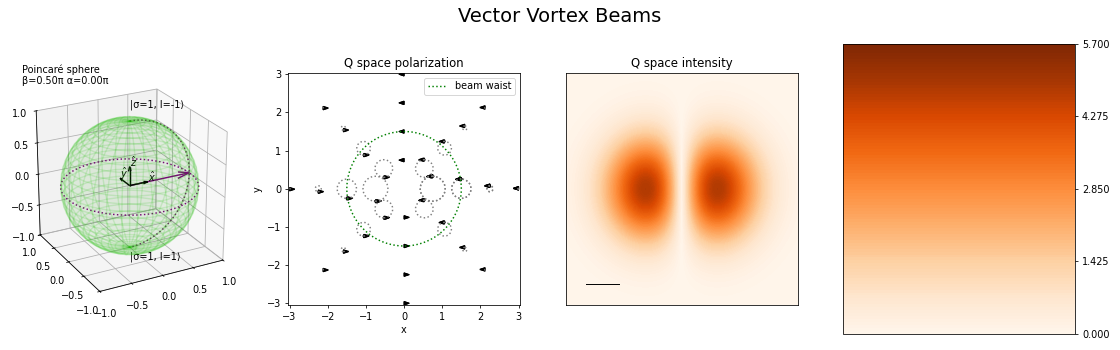

In [26]:
W, sigma1, sigma2 = 1.5, 1, 1
t = np.arange(0, 2*np.pi, 0.02)
circle, polar = np.linspace(0, 2*np.pi, 100), np.linspace(0, np.pi, 100)

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 6, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Sphere mesh
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx, sy, sz = np.cos(U)*np.sin(V), np.sin(U)*np.sin(V), np.cos(V)

# 依要求定義新的範圍限制
limit = 0.5 * Q_c / np.sqrt(2)

# Layout & Widgets
fig = plt.figure(figsize=(16,5), dpi=70)

beta_slider = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
l1_box, l2_box, p_box = widgets.IntText(value=-1, description='l'), widgets.IntText(value=1, description="l'"), widgets.IntText(value=0, description='p')

def update_plot(l1, l2, p, beta, alpha):
    beta, alpha = beta * np.pi, alpha * np.pi
    
    # 徹底清除舊圖記憶，防止 3D 繪圖組件與導引圓縮放異常
    fig.clear()
    
    # 重新建立子圖
    ax3D = fig.add_subplot(1, 4, 1, projection='3d')
    ax_pol = fig.add_subplot(1, 4, 2)
    ax_int = fig.add_subplot(1, 4, 3)
    cax = fig.add_subplot(1, 4, 4)
    
    for ax in [ax3D, ax_pol, ax_int]: ax.set_aspect('equal')

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(sx, sy, sz, color=(0.15,0.8,0.05,0.15))
    ax3D.plot_surface(sx, sy, sz, color=(0.15,0.8,0.05,0.05))
    
    qx, qy, qz = np.cos(alpha)*np.sin(beta), np.sin(alpha)*np.sin(beta), np.cos(beta)
    
    # 繪製紫色偏振態向量與黑色基準軸（限制箭頭比例）
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    # 修正純虛線導引圓（無 'p' 標記）
    ax3D.plot(np.sin(beta)*np.cos(circle), np.sin(beta)*np.sin(circle), np.cos(beta)+0*circle, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar)*np.cos(alpha), np.sin(polar)*np.sin(alpha), np.cos(polar), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩'); ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1,1); ax3D.set_ylim(-1,1); ax3D.set_zlim(-1,1); ax3D.view_init(24, -118)

    # ===================================================
    # 2. Real-space polarization
    # ===================================================
    for ang in np.linspace(0, 2*np.pi, 9):
        for R in np.linspace(W/2, 2*W, 4):
            x, y = R*np.cos(ang), R*np.sin(ang)
            a = 0.1 * VVBux(ang, R, l1, l2, beta, alpha)
            b = 0.1 * VVBuy(ang, R, sigma1, sigma2, l1, l2, beta, alpha)
            traj_x, traj_y = x + a*np.exp(-1j*w*t), y + b*np.exp(-1j*w*t)

            ax_pol.plot(np.real(traj_x), np.real(traj_y), ':', color='gray')
            for idx, step in [(-5, -1), (0, 5)]:
                ax_pol.arrow(np.real(traj_x[idx]), np.real(traj_y[idx]), 
                             np.real(traj_x[step]-traj_x[idx]), np.real(traj_y[step]-traj_y[idx]), width=0.03, color='k')

    ax_pol.plot(W*np.cos(t), W*np.sin(t), 'g:', label='beam waist')
    ax_pol.set_title("Q space polarization"); ax_pol.set_xlabel("x"); ax_pol.set_ylabel("y")
    ax_pol.legend()
    # 加上範圍限制
    ax_pol.set_xlim(-limit, limit); ax_pol.set_ylim(-limit, limit)

    # ===================================================
    # 3. Intensity
    # ===================================================
    I = VVBsity(phiq, q, sigma1, sigma2, l1, l2, beta, alpha)

    contour = ax_int.contourf(X, Y, I, levels=np.linspace(0, 5.7, 100), cmap='Oranges')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    ax_int.set_title("Q space intensity"); ax_int.set_xticks([]); ax_int.set_yticks([])
    # 加上範圍限制
    ax_int.set_xlim(-limit, limit); ax_int.set_ylim(-limit, limit)

    plt.colorbar(contour, cax=cax, ticks=np.linspace(0, 5.7, 5))
    
    plt.suptitle("Vector Vortex Beams", fontsize=20)
    plt.tight_layout()
    print(f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π')

out = widgets.interactive_output(update_plot, {'l1':l1_box, 'l2':l2_box, 'p':p_box, 'beta':beta_slider, 'alpha':alpha_slider})
ui = widgets.VBox([widgets.Label("coefficient"), widgets.HBox([l1_box, l2_box, p_box]), widgets.Label("parameter"), widgets.HBox([beta_slider, alpha_slider])])
display(ui, out)

Output()

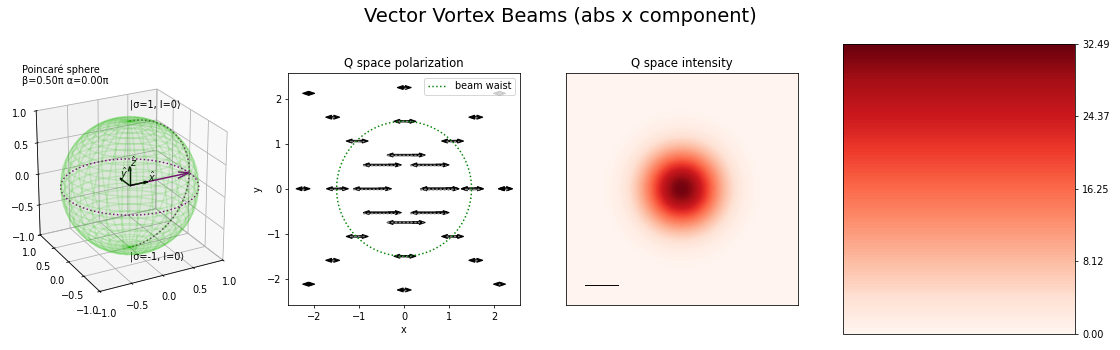

In [7]:
W, sigma1, sigma2 = 1.5, 1, -1
t = np.arange(0, 2*np.pi, 0.02)
circle, polar = np.linspace(0, 2*np.pi, 100), np.linspace(0, np.pi, 100)

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 1.2*Q_c, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Sphere mesh
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx, sy, sz = np.cos(U)*np.sin(V), np.sin(U)*np.sin(V), np.cos(V)

# Layout & Widgets
fig = plt.figure(figsize=(16,5), dpi=70)

beta_slider = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
l1_box, l2_box, p_box = widgets.IntText(value=0, description='l'), widgets.IntText(value=0, description="l'"), widgets.IntText(value=0, description='p')

def update_plot(l1, l2, p, beta, alpha):
    beta, alpha = beta * np.pi, alpha * np.pi
    
    # 清除舊圖
    fig.clear()
    
    # 建立子圖
    ax3D = fig.add_subplot(1, 4, 1, projection='3d')
    ax_pol = fig.add_subplot(1, 4, 2)
    ax_int = fig.add_subplot(1, 4, 3)
    cax = fig.add_subplot(1, 4, 4)
    
    ax3D.set_aspect('equal')
    ax_pol.set_aspect('equal')
    ax_int.set_aspect('equal')

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(sx, sy, sz, color=(0.15,0.8,0.05,0.15))
    ax3D.plot_surface(sx, sy, sz, color=(0.15,0.8,0.05,0.05))
    
    qx, qy, qz = np.cos(alpha)*np.sin(beta), np.sin(alpha)*np.sin(beta), np.cos(beta)
    
    # 偏振態向量改回用原本的標準 quiver，限制箭頭比例 (arrow_length_ratio)
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    
    # 畫出三個標準黑色坐標軸
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    # 【破案關鍵修正】：把 'p:' 改成 ':'，拿掉五角星標記，恢復成優雅的細虛線導引圓
    ax3D.plot(np.sin(beta)*np.cos(circle), np.sin(beta)*np.sin(circle), np.cos(beta)+0*circle, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar)*np.cos(alpha), np.sin(polar)*np.sin(alpha), np.cos(polar), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩')
    ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1,1); ax3D.set_ylim(-1,1); ax3D.set_zlim(-1,1); ax3D.view_init(24, -118)

    # ===================================================
    # 2. Real-space polarization
    # ===================================================
    for ang in np.linspace(0, 2*np.pi, 9):
        for R in np.linspace(W/2, 2*W, 4):
            x, y = R*np.cos(ang), R*np.sin(ang)
            a = 0.1 * VVBux(ang, R, l1, l2, beta, alpha)
            b = 0.1 * VVBuy(ang, R, sigma1, sigma2, l1, l2, beta, alpha)
            traj_x, traj_y = x + a*np.exp(-1j*w*t), y + b*np.exp(-1j*w*t)

            ax_pol.plot(np.real(traj_x), np.real(traj_y), ':', color='gray')
            for idx, step in [(-5, -1), (0, 5)]:
                ax_pol.arrow(np.real(traj_x[idx]), np.real(traj_y[idx]), 
                             np.real(traj_x[step]-traj_x[idx]), np.real(traj_y[step]-traj_y[idx]), width=0.03, color='k')

    ax_pol.plot(W*np.cos(t), W*np.sin(t), 'g:', label='beam waist')
    ax_pol.set_title("Q space polarization"); ax_pol.set_xlabel("x"); ax_pol.set_ylabel("y")
    ax_pol.set_xlim(-0.3*Qc, 0.3*Qc); ax_pol.set_ylim(-0.3*Qc, 0.3*Qc); ax_pol.legend()

    # ===================================================
    # 3. Intensity
    # ===================================================
    I = np.abs(VVBux(phiq, q, l1, l2, beta, alpha))**2
    contour = ax_int.contourf(X, Y, I, levels=np.linspace(0, 32.49, 100), cmap='Reds')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    ax_int.set_title("Q space intensity"); ax_int.set_xticks([]); ax_int.set_yticks([]); ax_int.set_xlim(-3,3); ax_int.set_ylim(-3,3)

    plt.colorbar(contour, cax=cax, ticks=np.linspace(0, 32.49, 5))
    
    plt.suptitle("Vector Vortex Beams (abs x component)", fontsize=20)
    plt.tight_layout()
    print(f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π')

out = widgets.interactive_output(update_plot, {'l1':l1_box, 'l2':l2_box, 'p':p_box, 'beta':beta_slider, 'alpha':alpha_slider})
ui = widgets.VBox([widgets.Label("coefficient"), widgets.HBox([l1_box, l2_box, p_box]), widgets.Label("parameter"), widgets.HBox([beta_slider, alpha_slider])])
display(ui, out)

Output()

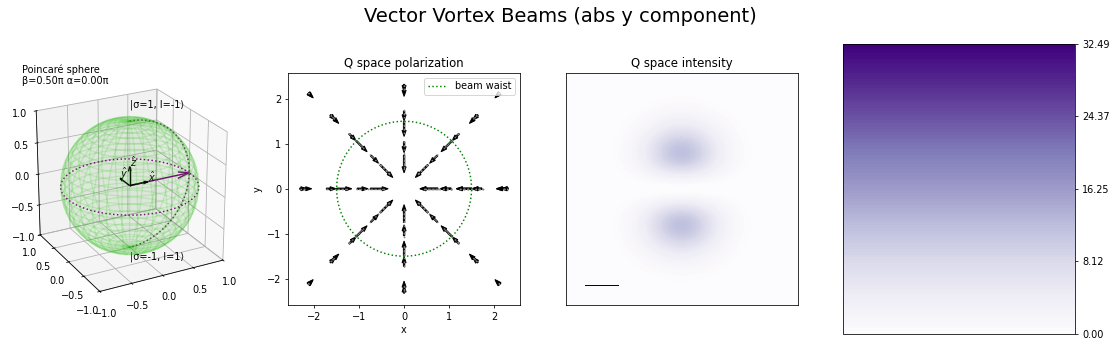

In [8]:
W, sigma1, sigma2 = 1.5, 1, -1
t = np.arange(0, 2*np.pi, 0.02)
circle, polar = np.linspace(0, 2*np.pi, 100), np.linspace(0, np.pi, 100)

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 1.2*Q_c, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Sphere mesh
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx, sy, sz = np.cos(U)*np.sin(V), np.sin(U)*np.sin(V), np.cos(V)

# Layout & Widgets
fig = plt.figure(figsize=(16,5), dpi=70)

beta_slider = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
l1_box, l2_box, p_box = widgets.IntText(value=-1, description='l'), widgets.IntText(value=1, description="l'"), widgets.IntText(value=0, description='p')

def update_plot(l1, l2, p, beta, alpha):
    beta, alpha = beta * np.pi, alpha * np.pi
    
    # 徹底清除舊圖記憶，防止 3D quiver 與導引圓縮放異常
    fig.clear()
    
    # 重新建立子圖
    ax3D = fig.add_subplot(1, 4, 1, projection='3d')
    ax_pol = fig.add_subplot(1, 4, 2)
    ax_int = fig.add_subplot(1, 4, 3)
    cax = fig.add_subplot(1, 4, 4)
    
    ax3D.set_aspect('equal')
    ax_pol.set_aspect('equal')
    ax_int.set_aspect('equal')

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(sx, sy, sz, color=(0.15,0.8,0.05,0.15))
    ax3D.plot_surface(sx, sy, sz, color=(0.15,0.8,0.05,0.05))
    
    qx, qy, qz = np.cos(alpha)*np.sin(beta), np.sin(alpha)*np.sin(beta), np.cos(beta)
    
    # 標示偏振態向量，限制箭頭比例 (arrow_length_ratio)
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    
    # 畫出三個標準黑色坐標軸
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    # 修正：使用正確的 'dotted' 純虛線樣式，拿掉會產生肥毛蟲的 'p' 標記
    ax3D.plot(np.sin(beta)*np.cos(circle), np.sin(beta)*np.sin(circle), np.cos(beta)+0*circle, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar)*np.cos(alpha), np.sin(polar)*np.sin(alpha), np.cos(polar), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩')
    ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1,1); ax3D.set_ylim(-1,1); ax3D.set_zlim(-1,1); ax3D.view_init(24, -118)

    # ===================================================
    # 2. Real-space polarization
    # ===================================================
    for ang in np.linspace(0, 2*np.pi, 9):
        for R in np.linspace(W/2, 2*W, 4):
            x, y = R*np.cos(ang), R*np.sin(ang)
            a = 0.1 * VVBux(ang, R, l1, l2, beta, alpha)
            b = 0.1 * VVBuy(ang, R, sigma1, sigma2, l1, l2, beta, alpha)
            traj_x, traj_y = x + a*np.exp(-1j*w*t), y + b*np.exp(-1j*w*t)

            ax_pol.plot(np.real(traj_x), np.real(traj_y), ':', color='gray')
            for idx, step in [(-5, -1), (0, 5)]:
                ax_pol.arrow(np.real(traj_x[idx]), np.real(traj_y[idx]), 
                             np.real(traj_x[step]-traj_x[idx]), np.real(traj_y[step]-traj_y[idx]), width=0.03, color='k')

    ax_pol.plot(W*np.cos(t), W*np.sin(t), 'g:', label='beam waist')
    ax_pol.set_title("Q space polarization"); ax_pol.set_xlabel("x"); ax_pol.set_ylabel("y")
    ax_pol.set_xlim(-0.3*Qc, 0.3*Qc); ax_pol.set_ylim(-0.3*Qc, 0.3*Qc); ax_pol.legend()

    # ===================================================
    # 3. Intensity (這裡已對應為 y 分量強度的 VVBuy 與 Purples 色階)
    # ===================================================
    I = np.abs(VVBuy(phiq, q, sigma1, sigma2, l1, l2, beta, alpha))**2
    contour = ax_int.contourf(X, Y, I, levels=np.linspace(0, 32.49, 100), cmap='Purples')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    ax_int.set_title("Q space intensity"); ax_int.set_xticks([]); ax_int.set_yticks([]); ax_int.set_xlim(-3,3); ax_int.set_ylim(-3,3)

    plt.colorbar(contour, cax=cax, ticks=np.linspace(0, 32.49, 5))
    
    # 重新整理總標題與佈局
    plt.suptitle("Vector Vortex Beams (abs y component)", fontsize=20)
    plt.tight_layout()
    print(f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π')

out = widgets.interactive_output(update_plot, {'l1':l1_box, 'l2':l2_box, 'p':p_box, 'beta':beta_slider, 'alpha':alpha_slider})
ui = widgets.VBox([widgets.Label("coefficient"), widgets.HBox([l1_box, l2_box, p_box]), widgets.Label("parameter"), widgets.HBox([beta_slider, alpha_slider])])
display(ui, out)

Output()

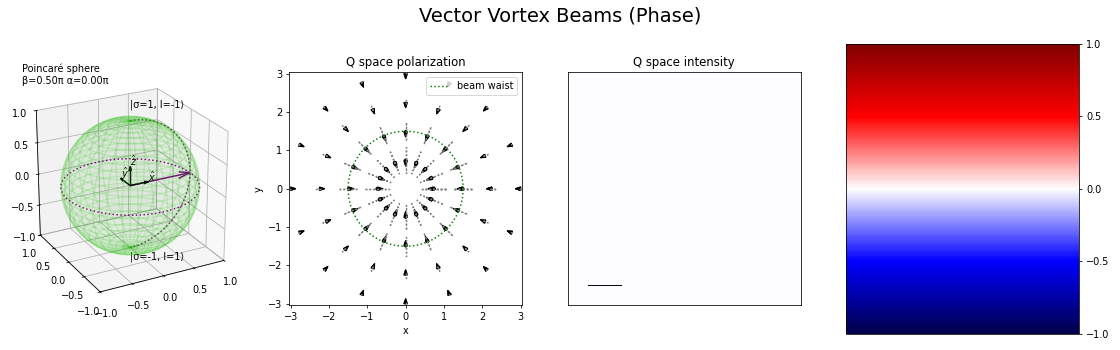

In [13]:
W, sigma1, sigma2 = 1.5, 1, -1
t = np.arange(0, 2*np.pi, 0.02)
circle, polar = np.linspace(0, 2*np.pi, 100), np.linspace(0, np.pi, 100)

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 5*Q_c, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Sphere mesh
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx, sy, sz = np.cos(U)*np.sin(V), np.sin(U)*np.sin(V), np.cos(V)

# Layout & Widgets
fig = plt.figure(figsize=(16,5), dpi=70)

beta_slider = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
l1_box, l2_box, p_box = widgets.IntText(value=-1, description='l'), widgets.IntText(value=1, description="l'"), widgets.IntText(value=0, description='p')

def update_plot(l1, l2, p, beta, alpha):
    beta, alpha = beta * np.pi, alpha * np.pi
    
    # 徹底清除舊圖記憶，防止 3D 繪圖組件縮放異常
    fig.clear()
    
    # 重新建立子圖
    ax3D = fig.add_subplot(1, 4, 1, projection='3d')
    ax_pol = fig.add_subplot(1, 4, 2)
    ax_int = fig.add_subplot(1, 4, 3)
    cax = fig.add_subplot(1, 4, 4)
    
    for ax in [ax3D, ax_pol, ax_int]: ax.set_aspect('equal')

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(sx, sy, sz, color=(0.15,0.8,0.05,0.15))
    ax3D.plot_surface(sx, sy, sz, color=(0.15,0.8,0.05,0.05))
    
    qx, qy, qz = np.cos(alpha)*np.sin(beta), np.sin(alpha)*np.sin(beta), np.cos(beta)
    
    # 繪製紫色偏振態向量與黑色基準軸（限制箭頭比例）
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    # 修正純虛線導引圓（無 'p' 標記）
    ax3D.plot(np.sin(beta)*np.cos(circle), np.sin(beta)*np.sin(circle), np.cos(beta)+0*circle, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar)*np.cos(alpha), np.sin(polar)*np.sin(alpha), np.cos(polar), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩'); ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1,1); ax3D.set_ylim(-1,1); ax3D.set_zlim(-1,1); ax3D.view_init(24, -118)

    # ===================================================
    # 2. Real-space polarization
    # ===================================================
    for ang in np.linspace(0, 2*np.pi, 17):
        for R in np.linspace(W/2, 2*W, 4):
            x, y = R*np.cos(ang), R*np.sin(ang)
            a = 0.1 * VVBux(ang, R, l1, l2, beta, alpha)
            b = 0.1 * VVBuy(ang, R, sigma1, sigma2, l1, l2, beta, alpha)
            traj_x, traj_y = x + a*np.exp(-1j*w*t), y + b*np.exp(-1j*w*t)

            ax_pol.plot(np.real(traj_x), np.real(traj_y), ':', color='gray')
            for idx, step in [(-5, -1), (0, 5)]:
                ax_pol.arrow(np.real(traj_x[idx]), np.real(traj_y[idx]), 
                             np.real(traj_x[step]-traj_x[idx]), np.real(traj_y[step]-traj_y[idx]), width=0.03, color='k')

    ax_pol.plot(W*np.cos(t), W*np.sin(t), 'g:', label='beam waist')
    ax_pol.set_title("Q space polarization"); ax_pol.set_xlabel("x"); ax_pol.set_ylabel("y")
    ax_pol.set_xlim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2)); ax_pol.set_ylim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2)); ax_pol.legend()

    # ===================================================
    # 3. Intensity (Phase Difference Map)
    # ===================================================
    Ex = VVBux(phiq, q, l1, l2, beta, alpha)
    Ey = VVBuy(phiq, q, sigma1, sigma2, l1, l2, beta, alpha)
    I = np.real(Ex)/5.67 #seismic
    # I = np.real(Ey)/5.67
    
    # I = np.imag(Ex)/5.67 #PRGn
    # I = np.imag(Ey)/5.67
    
    contour = ax_int.contourf(X, Y, I, levels=np.linspace(-1, 1, 500), cmap='seismic')
    # contour = ax_int.contourf(X, Y, I, levels=np.linspace(-1, 1, 500), cmap='PRGn')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    ax_int.set_title("Q space intensity"); ax_int.set_xticks([]); ax_int.set_yticks([]); ax_int.set_xlim(-3,3); ax_int.set_ylim(-3,3)
    ax_int.set_xlim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2)); ax_int.set_ylim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2))
    
    plt.colorbar(contour, cax=cax, ticks=np.linspace(-1, 1, 5))
    
    plt.suptitle("Vector Vortex Beams (Phase)", fontsize=20)
    plt.tight_layout()
    print(f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π')

out = widgets.interactive_output(update_plot, {'l1':l1_box, 'l2':l2_box, 'p':p_box, 'beta':beta_slider, 'alpha':alpha_slider})
ui = widgets.VBox([widgets.Label("coefficient"), widgets.HBox([l1_box, l2_box, p_box]), widgets.Label("parameter"), widgets.HBox([beta_slider, alpha_slider])])
display(ui, out)

In [74]:
Lambda = 0.532 #um
q_0 = 2*np.pi/Lambda # um-1
w = c*q_0*10**(-6)
W = 1.5 #um
ZR = 1/2 * q_0 * (W**2) # um-1
Qc = 8.6 #um-1
print(q_0, w, ZR)

def F(phiq,q,l):
    F = (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) 
    return F

def uz(phiq,q,sigma,l):
    uz = -1/np.sqrt(2) * (q/np.sqrt(q**2+q_0**2)) * F(phiq,q,l)*np.exp(complex(0,1)*(sigma+l)*phiq)
    return uz

# def VVBuz(phiq,q,sigma1,sigma2,l1,l2,beta,alpha):
#     VVBuz = np.cos(beta/2)*uz(phiq,q,sigma1,l1)+np.exp(complex(0,1)*alpha)*np.sin(beta/2)*uz(phiq,q,sigma2,l2)
#     VVBuz = np.abs(VVBuz)
#     return VVBuz

def VVBuz(phiq,q,sigma1,sigma2,l1,l2,beta,alpha):
    VVBuz = -1/np.sqrt(2)* (q/np.sqrt(q**2+q_0**2))*np.exp(complex(0,1)*((sigma1+sigma2+l1+l2)/2*phiq+alpha/2))*(np.cos(((l2-l1+sigma2-sigma1)*phiq+alpha)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))  +  complex(0,1)*np.cos(((l2-l1+sigma2-sigma1)*phiq+alpha+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2)))
    VVBuz = np.abs(VVBuz)
    return VVBuz

# def VVBuz(phiq,q,sigma1,sigma2,l1,l2,beta,alpha):
#     VVBuz = -1/np.sqrt(2)* (q/np.sqrt(q**2+q_0**2))*np.exp(complex(0,1)*((sigma1+sigma2+l1+l2)/2*phiq+alpha/2))*(complex(0,1)*np.cos(((l2-l1+sigma2-sigma1)*phiq+alpha+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2)))
#     VVBuz = np.abs(VVBuz)
#     return VVBuz


11.810498697705988 3540.698434791077 13.286811034919236


Output()

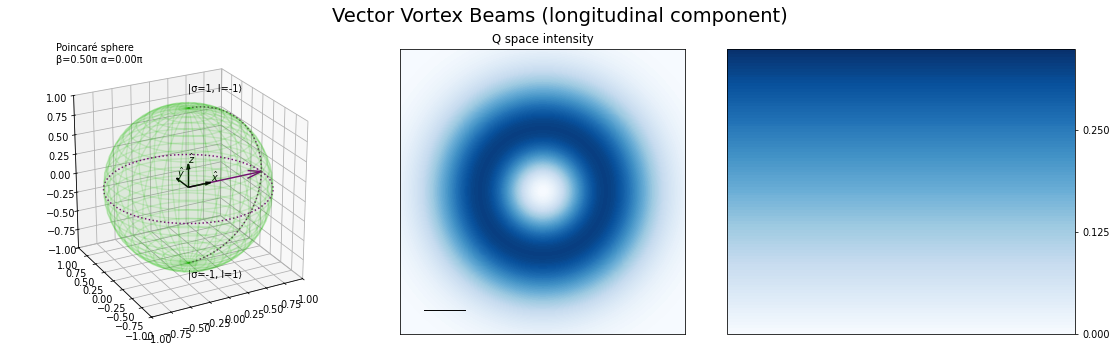

In [24]:
W, sigma1, sigma2 = 1.5, 1, -1
t = np.arange(0, 2*np.pi, 0.02)
circle, polar = np.linspace(0, 2*np.pi, 100), np.linspace(0, np.pi, 100)

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 6, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Sphere mesh
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx, sy, sz = np.cos(U)*np.sin(V), np.sin(U)*np.sin(V), np.cos(V)

# Layout & Widgets
fig = plt.figure(figsize=(16,5), dpi=70)

beta_slider = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
l1_box, l2_box, p_box = widgets.IntText(value=-1, description='l'), widgets.IntText(value=1, description="l'"), widgets.IntText(value=0, description='p')

def update_plot(l1, l2, p, beta, alpha):
    beta, alpha = beta * np.pi, alpha * np.pi
    
    # 徹底清除舊圖記憶，防止 3D quiver 與導引圓縮放異常
    fig.clear()
    
    # 重新建立子圖 (1, 3, i)
    ax3D = fig.add_subplot(1, 3, 1, projection='3d')
    ax_int = fig.add_subplot(1, 3, 2)
    cax = fig.add_subplot(1, 3, 3)
    
    ax3D.set_aspect('equal')
    ax_int.set_aspect('equal')

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(sx, sy, sz, color=(0.15,0.8,0.05,0.15))
    ax3D.plot_surface(sx, sy, sz, color=(0.15,0.8,0.05,0.05))
    
    qx, qy, qz = np.cos(alpha)*np.sin(beta), np.sin(alpha)*np.sin(beta), np.cos(beta)
    
    # 標示偏振態向量，限制箭頭比例 (arrow_length_ratio)
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    
    # 畫出三個標準黑色坐標軸
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    # 修正：使用正確的 'dotted' 純虛線樣式，無 'p' 標記
    ax3D.plot(np.sin(beta)*np.cos(circle), np.sin(beta)*np.sin(circle), np.cos(beta)+0*circle, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar)*np.cos(alpha), np.sin(polar)*np.sin(alpha), np.cos(polar), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩'); ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1,1); ax3D.set_ylim(-1,1); ax3D.set_zlim(-1,1); ax3D.view_init(24, -118)

    # ===================================================
    # 2. Intensity (Longitudinal component: VVBuz, Blues 色階)
    # ===================================================
    I = VVBuz(phiq, q, sigma1, sigma2, l1, l2, beta, alpha)

    contour = ax_int.contourf(X, Y, I, levels=np.linspace(0, 0.35, 100), cmap='Blues')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    ax_int.set_title("Q space intensity"); ax_int.set_xticks([]); ax_int.set_yticks([]); ax_int.set_xlim(-3,3); ax_int.set_ylim(-3,3)

    plt.colorbar(contour, cax=cax, ticks=np.linspace(0, 0.5, 5))
    
    plt.suptitle("Vector Vortex Beams (longitudinal component)", fontsize=20)
    plt.tight_layout()
    print(f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π')

out = widgets.interactive_output(update_plot, {'l1':l1_box, 'l2':l2_box, 'p':p_box, 'beta':beta_slider, 'alpha':alpha_slider})
ui = widgets.VBox([widgets.Label("coefficient"), widgets.HBox([l1_box, l2_box, p_box]), widgets.Label("parameter"), widgets.HBox([beta_slider, alpha_slider])])
display(ui, out)

In [81]:
def F(phiq,q,l):
    F = (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) 
    return F

def VVBuz(phiq,q,sigma1,sigma2,l1,l2,beta,alpha):
    VVBuz = -1/np.sqrt(2)* (q/np.sqrt(q**2+q_0**2))*np.exp(complex(0,1)*((sigma1+sigma2+l1+l2)/2*phiq+alpha/2))*(np.cos(((l2-l1+sigma2-sigma1)*phiq+alpha)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))  +  complex(0,1)*np.cos(((l2-l1+sigma2-sigma1)*phiq+alpha+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2)))
    VVBuz = np.real(VVBuz)
    return VVBuz

Output()

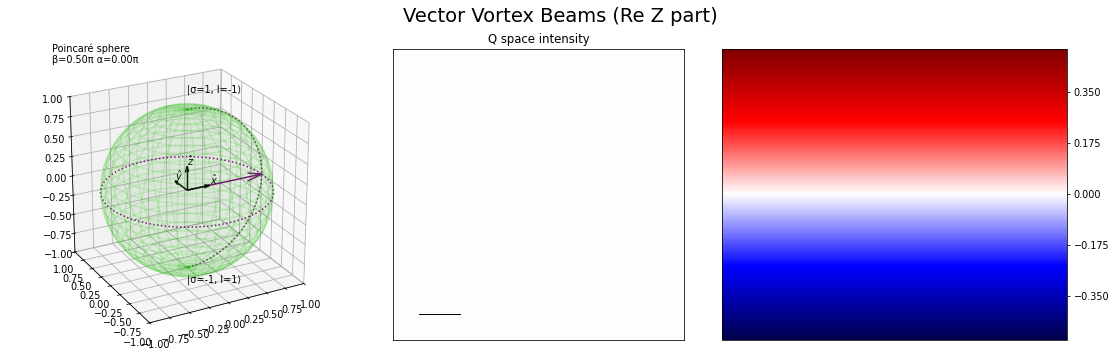

In [82]:
W, sigma1, sigma2 = 1.5, 1, -1

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 5*Q_c, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Sphere mesh
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx, sy, sz = np.cos(U)*np.sin(V), np.sin(U)*np.sin(V), np.cos(V)

# Layout & Widgets
fig = plt.figure(figsize=(16,5), dpi=70)

beta_slider = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
l1_box, l2_box, p_box = widgets.IntText(value=-1, description='l'), widgets.IntText(value=1, description="l'"), widgets.IntText(value=0, description='p')

def update_plot(l1, l2, p, beta, alpha):
    beta, alpha = beta * np.pi, alpha * np.pi
    
    # 徹底清除舊圖記憶，防止 3D 繪圖組件縮放異常
    fig.clear()
    
    # 重新建立子圖
    ax3D = fig.add_subplot(1, 3, 1, projection='3d')
    ax_int = fig.add_subplot(1, 3, 2)
    cax = fig.add_subplot(1, 3, 3)
    
    for ax in [ax3D, ax_int]: ax.set_aspect('equal')

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(sx, sy, sz, color=(0.15,0.8,0.05,0.15))
    ax3D.plot_surface(sx, sy, sz, color=(0.15,0.8,0.05,0.05))
    
    qx, qy, qz = np.cos(alpha)*np.sin(beta), np.sin(alpha)*np.sin(beta), np.cos(beta)
    
    # 繪製紫色偏振態向量與黑色基準軸（限制箭頭比例）
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    # 修正純虛線導引圓（無 'p' 標記）
    ax3D.plot(np.sin(beta)*np.cos(circle), np.sin(beta)*np.sin(circle), np.cos(beta)+0*circle, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar)*np.cos(alpha), np.sin(polar)*np.sin(alpha), np.cos(polar), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩'); ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1,1); ax3D.set_ylim(-1,1); ax3D.set_zlim(-1,1); ax3D.view_init(24, -118)

    # ===================================================
    # 3. Intensity (Phase Difference Map)
    # ===================================================
    I = VVBuz(phiq, q, sigma1, sigma2, l1, l2, beta, alpha)
    
    contour = ax_int.contourf(X, Y, I, levels=np.linspace(-0.5, 0.5, 500), cmap='seismic')
    # contour = ax_int.contourf(X, Y, I, levels=np.linspace(-1, 1, 500), cmap='PRGn')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    ax_int.set_title("Q space intensity"); ax_int.set_xticks([]); ax_int.set_yticks([]); ax_int.set_xlim(-3,3); ax_int.set_ylim(-3,3)
    ax_int.set_xlim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2)); ax_int.set_ylim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2))
    
    plt.colorbar(contour, cax=cax, ticks=np.linspace(-0.35, 0.35, 5))
    
    plt.suptitle("Vector Vortex Beams (Re Z part)", fontsize=20)
    plt.tight_layout()
    print(f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π')

out = widgets.interactive_output(update_plot, {'l1':l1_box, 'l2':l2_box, 'p':p_box, 'beta':beta_slider, 'alpha':alpha_slider})
ui = widgets.VBox([widgets.Label("coefficient"), widgets.HBox([l1_box, l2_box, p_box]), widgets.Label("parameter"), widgets.HBox([beta_slider, alpha_slider])])
display(ui, out)

In [138]:
def VVBuz(phiq,q,sigma1,sigma2,l1,l2,beta,alpha):
    VVBuz = -1/np.sqrt(2)* (q/np.sqrt(q**2+q_0**2))*np.exp(complex(0,1)*((sigma1+sigma2+l1+l2)/2*phiq+alpha/2))*(np.cos(((l2-l1+sigma2-sigma1)*phiq+alpha)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))  +  complex(0,1)*np.cos(((l2-l1+sigma2-sigma1)*phiq+alpha+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2)))
    VVBuz = np.imag(VVBuz)
    return VVBuz

Output()

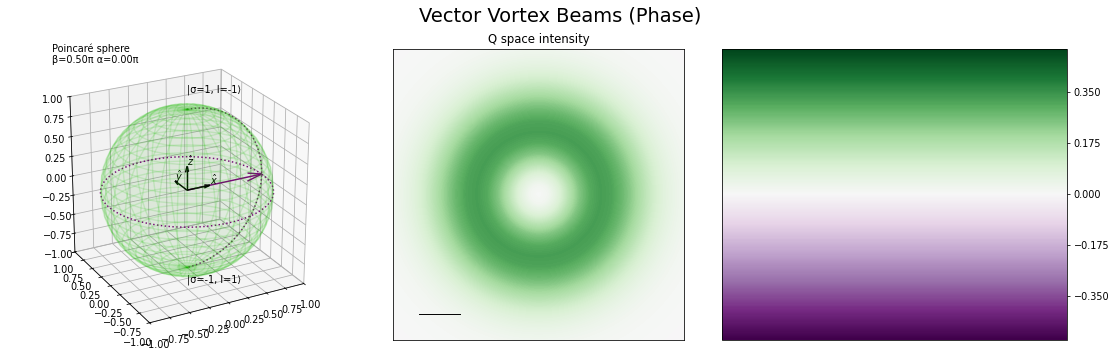

In [139]:
W, sigma1, sigma2 = 1.5, 1, -1

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 5*Q_c, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Sphere mesh
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx, sy, sz = np.cos(U)*np.sin(V), np.sin(U)*np.sin(V), np.cos(V)

# Layout & Widgets
fig = plt.figure(figsize=(16,5), dpi=70)

beta_slider = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
l1_box, l2_box, p_box = widgets.IntText(value=-1, description='l'), widgets.IntText(value=1, description="l'"), widgets.IntText(value=0, description='p')

def update_plot(l1, l2, p, beta, alpha):
    beta, alpha = beta * np.pi, alpha * np.pi
    
    # 徹底清除舊圖記憶，防止 3D 繪圖組件縮放異常
    fig.clear()
    
    # 重新建立子圖
    ax3D = fig.add_subplot(1, 3, 1, projection='3d')
    ax_int = fig.add_subplot(1, 3, 2)
    cax = fig.add_subplot(1, 3, 3)
    
    for ax in [ax3D, ax_int]: ax.set_aspect('equal')

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(sx, sy, sz, color=(0.15,0.8,0.05,0.15))
    ax3D.plot_surface(sx, sy, sz, color=(0.15,0.8,0.05,0.05))
    
    qx, qy, qz = np.cos(alpha)*np.sin(beta), np.sin(alpha)*np.sin(beta), np.cos(beta)
    
    # 繪製紫色偏振態向量與黑色基準軸（限制箭頭比例）
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    # 修正純虛線導引圓（無 'p' 標記）
    ax3D.plot(np.sin(beta)*np.cos(circle), np.sin(beta)*np.sin(circle), np.cos(beta)+0*circle, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar)*np.cos(alpha), np.sin(polar)*np.sin(alpha), np.cos(polar), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩'); ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1,1); ax3D.set_ylim(-1,1); ax3D.set_zlim(-1,1); ax3D.view_init(24, -118)

    # ===================================================
    # 3. Intensity (Phase Difference Map)
    # ===================================================
    I = VVBuz(phiq, q, sigma1, sigma2, l1, l2, beta, alpha)
    
    # contour = ax_int.contourf(X, Y, I, levels=np.linspace(-0.5, 0.5, 500), cmap='seismic')
    contour = ax_int.contourf(X, Y, I, levels=np.linspace(-0.5, 0.5, 500), cmap='PRGn')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    ax_int.set_title("Q space intensity"); ax_int.set_xticks([]); ax_int.set_yticks([]); ax_int.set_xlim(-3,3); ax_int.set_ylim(-3,3)
    ax_int.set_xlim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2)); ax_int.set_ylim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2))
    
    plt.colorbar(contour, cax=cax, ticks=np.linspace(-0.35, 0.35, 5))
    
    plt.suptitle("Vector Vortex Beams (Im Z part)", fontsize=20)
    plt.tight_layout()
    print(f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π')

out = widgets.interactive_output(update_plot, {'l1':l1_box, 'l2':l2_box, 'p':p_box, 'beta':beta_slider, 'alpha':alpha_slider})
ui = widgets.VBox([widgets.Label("coefficient"), widgets.HBox([l1_box, l2_box, p_box]), widgets.Label("parameter"), widgets.HBox([beta_slider, alpha_slider])])
display(ui, out)

In [141]:
#test#

In [28]:
Lambda = 0.532 #um
q_0 = 2*np.pi/Lambda # um-1
w = c*q_0*10**(-6)
W = 1.5 #um
ZR = 1/2 * q_0 * (W**2) # um-1
Qc = 8.6 #um-1
print(q_0, w, ZR)

def F(phiq,q,l):
    # F = (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) 
    F = np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) 
    return F

# def VVBuz(phiq,q,sigma1,sigma2,l1,l2,beta,alpha):
    
#     DJ = l2-l1+sigma2-sigma1
#     TJ = (l2+l1+sigma2+sigma1)/2
    
#     VVBuz = np.cos((DJ*phiq+alpha)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))  +  complex(0,1)*np.cos((DJ*phiq+alpha+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2))
#     # VVBuz = np.cos((DJ*phiq+alpha)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))  
#     # VVBuz = complex(0,1)*np.cos((DJ*phiq+alpha+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2))
    
#     VVBuz *= -1/np.sqrt(2)* (q/np.sqrt(q**2+q_0**2))*np.exp(complex(0,1)*(TJ*phiq+alpha/2))
#     VVBuz = np.abs(VVBuz)
#     return VVBuz

def VVBuz(phiq,q,sigma1,sigma2,l1,l2,beta,alpha):
    
    DJ = l2-l1+sigma2-sigma1
    TJ = (l2+l1+sigma2+sigma1)/2
    Dabsl = np.abs(l2)-np.abs(l1)
    
    VVBuz = np.cos((DJ*phiq+alpha-np.pi*Dabsl/2)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))  +  complex(0,1)*np.cos((DJ*phiq+alpha-np.pi*Dabsl/2+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2))
    # VVBuz = np.cos((DJ*phiq+alpha-np.pi*Dabsl/2)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))
    # VVBuz = complex(0,1)*np.cos((DJ*phiq+alpha-np.pi*Dabsl/2+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2))
    
    VVBuz = -1/np.sqrt(2)* (q/np.sqrt(q**2+q_0**2))*np.exp(complex(0,1)*(TJ*phiq+alpha/2-np.pi*(np.abs(l2)+np.abs(l1))/4)) * VVBuz
    VVBuz = np.abs(VVBuz)
    return VVBuz


11.810498697705988 3540.698434791077 13.286811034919236


Output()

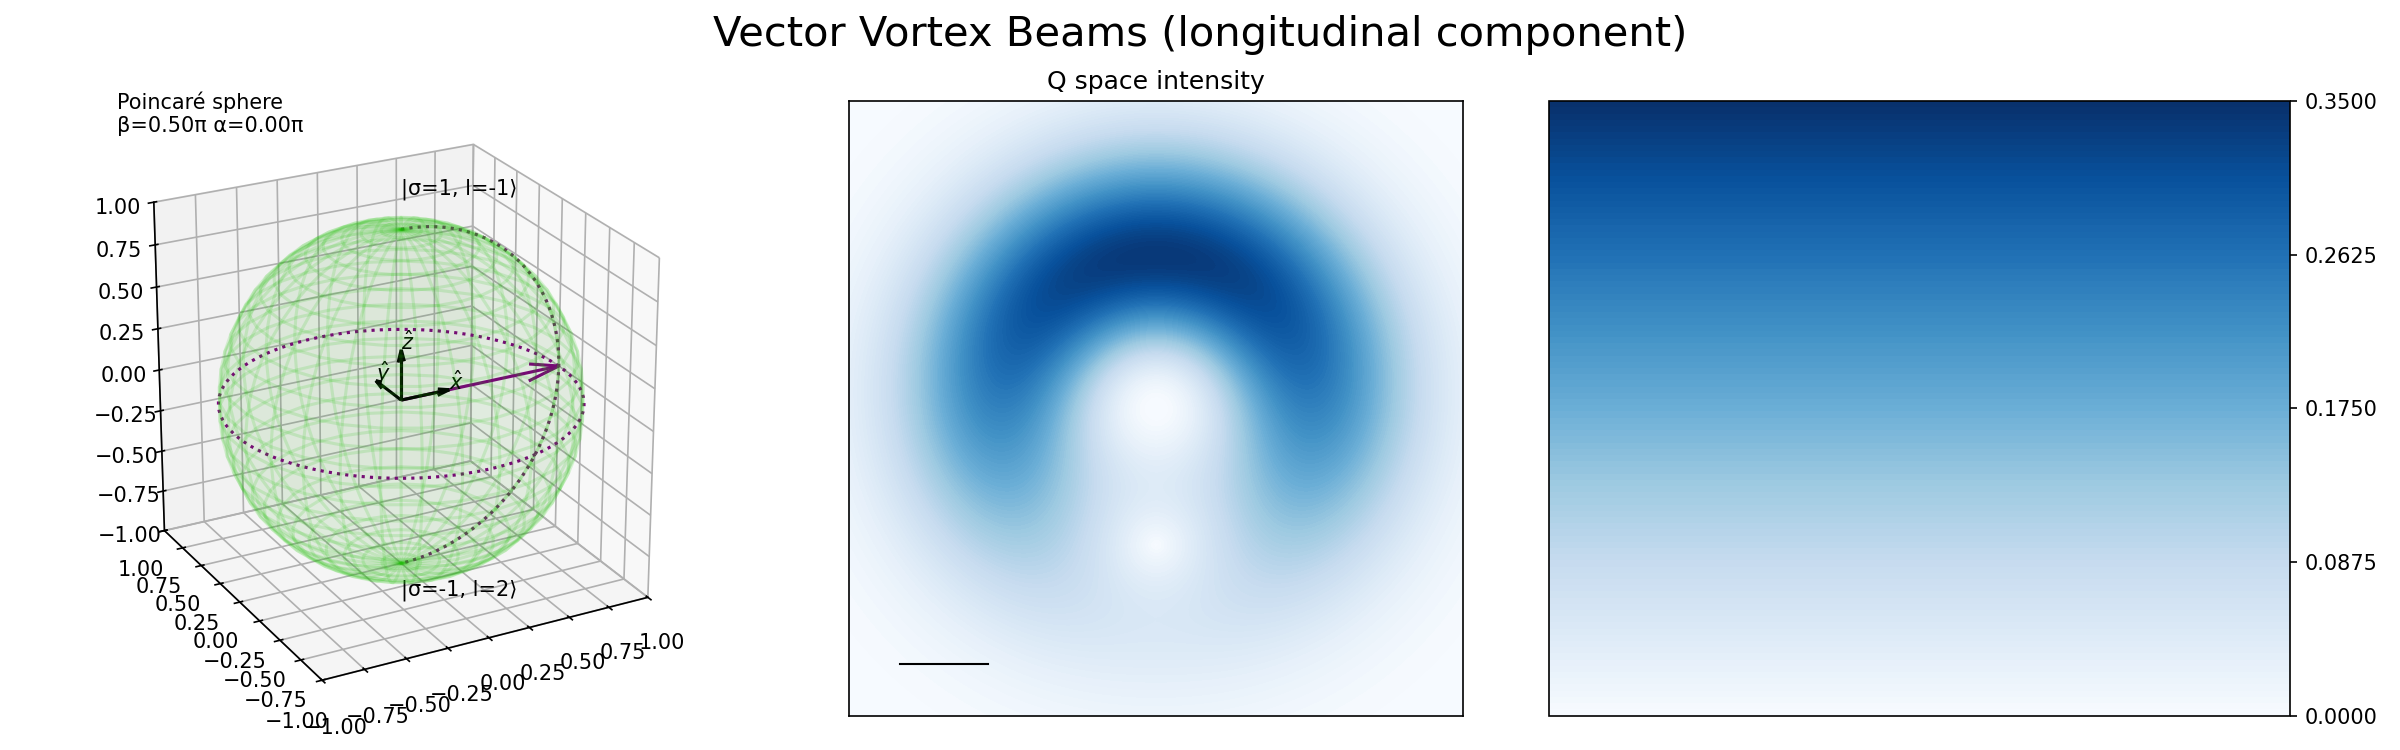

In [30]:
W, sigma1, sigma2 = 1.5, 1, -1
t = np.arange(0, 2*np.pi, 0.02)
circle, polar = np.linspace(0, 2*np.pi, 100), np.linspace(0, np.pi, 100)

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 6, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Sphere mesh
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx, sy, sz = np.cos(U)*np.sin(V), np.sin(U)*np.sin(V), np.cos(V)

# Layout & Widgets
fig = plt.figure(figsize=(16,5), dpi=150)

beta_slider = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
l1_box, l2_box, p_box = widgets.IntText(value=-1, description='l'), widgets.IntText(value=2, description="l'"), widgets.IntText(value=0, description='p')

def update_plot(l1, l2, p, beta, alpha):
    beta, alpha = beta * np.pi, alpha * np.pi
    
    # 徹底清除舊圖記憶，防止 3D quiver 與導引圓縮放異常
    fig.clear()
    
    # 重新建立子圖 (1, 3, i)
    ax3D = fig.add_subplot(1, 3, 1, projection='3d')
    ax_int = fig.add_subplot(1, 3, 2)
    cax = fig.add_subplot(1, 3, 3)
    
    ax3D.set_aspect('equal')
    ax_int.set_aspect('equal')

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(sx, sy, sz, color=(0.15,0.8,0.05,0.15))
    ax3D.plot_surface(sx, sy, sz, color=(0.15,0.8,0.05,0.05))
    
    qx, qy, qz = np.cos(alpha)*np.sin(beta), np.sin(alpha)*np.sin(beta), np.cos(beta)
    
    # 標示偏振態向量，限制箭頭比例 (arrow_length_ratio)
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    
    # 畫出三個標準黑色坐標軸
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    # 修正：使用正確的 'dotted' 純虛線樣式，無 'p' 標記
    ax3D.plot(np.sin(beta)*np.cos(circle), np.sin(beta)*np.sin(circle), np.cos(beta)+0*circle, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar)*np.cos(alpha), np.sin(polar)*np.sin(alpha), np.cos(polar), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩'); ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1,1); ax3D.set_ylim(-1,1); ax3D.set_zlim(-1,1); ax3D.view_init(24, -118)

    # ===================================================
    # 2. Intensity (Longitudinal component: VVBuz, Blues 色階)
    # ===================================================
    I = VVBuz(phiq, q, sigma1, sigma2, l1, l2, beta, alpha)
    
    TJ = (l2+l1+sigma2+sigma1)/2
    print('TJ=',TJ)

    contour = ax_int.contourf(X, Y, I, levels=np.linspace(0, 0.35, 100), cmap='Blues')
    # contour = ax_int.contourf(X, Y, I, levels=np.linspace(0, 0.1, 100), cmap='PuRd')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    ax_int.set_title("Q space intensity"); ax_int.set_xticks([]); ax_int.set_yticks([]); ax_int.set_xlim(-3,3); ax_int.set_ylim(-3,3)

    plt.colorbar(contour, cax=cax, ticks=np.linspace(0, 0.35, 5))
    
    plt.suptitle("Vector Vortex Beams (longitudinal component)", fontsize=20)
    plt.tight_layout()
    print(f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π')

out = widgets.interactive_output(update_plot, {'l1':l1_box, 'l2':l2_box, 'p':p_box, 'beta':beta_slider, 'alpha':alpha_slider})
ui = widgets.VBox([widgets.Label("coefficient"), widgets.HBox([l1_box, l2_box, p_box]), widgets.Label("parameter"), widgets.HBox([beta_slider, alpha_slider])])
display(ui, out)

In [109]:
Lambda = 0.532 #um
q_0 = 2*np.pi/Lambda # um-1
w = c*q_0*10**(-6)
W = 1.5 #um
ZR = 1/2 * q_0 * (W**2) # um-1
Qc = 8.6 #um-1
print(q_0, w, ZR)

def F(phiq,q,l):
    # F = (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) 
    F = np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) 
    return F

def VVBuz(phiq,q,sigma1,sigma2,l1,l2,beta,alpha, t):
    
    DJ = l2-l1+sigma2-sigma1
    TJ = (l2+l1+sigma2+sigma1)/2
    Dabsl = np.abs(l2)-np.abs(l1)
    Tabsl = (np.abs(l2)+np.abs(l1))/2
    
    VVBuz = np.cos(TJ*phiq-np.pi*Tabsl/2+alpha/2-w*t)*np.cos((DJ*phiq+alpha-np.pi*Dabsl/2)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))  -  np.sin(TJ*phiq-np.pi*Tabsl/2+alpha/2-w*t)*np.cos((DJ*phiq+alpha-np.pi*Dabsl/2+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2))
    # VVBuz = np.cos(TJ*phiq-np.pi*Tabsl/2+alpha/2-w*t)*np.cos((DJ*phiq+alpha-np.pi*Dabsl/2)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))
    # VVBuz = -  np.sin(TJ*phiq-np.pi*Tabsl/2+alpha/2-w*t)*np.cos((DJ*phiq+alpha-np.pi*Dabsl/2+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2))
    
    VVBuz = -1/np.sqrt(2)* (q/np.sqrt(q**2+q_0**2)) * VVBuz
    return VVBuz

print('T=2*pi/w=',2*np.pi/w)

11.810498697705988 3540.698434791077 13.286811034919236
T=2*pi/w= 0.0017745609864541691


Output()

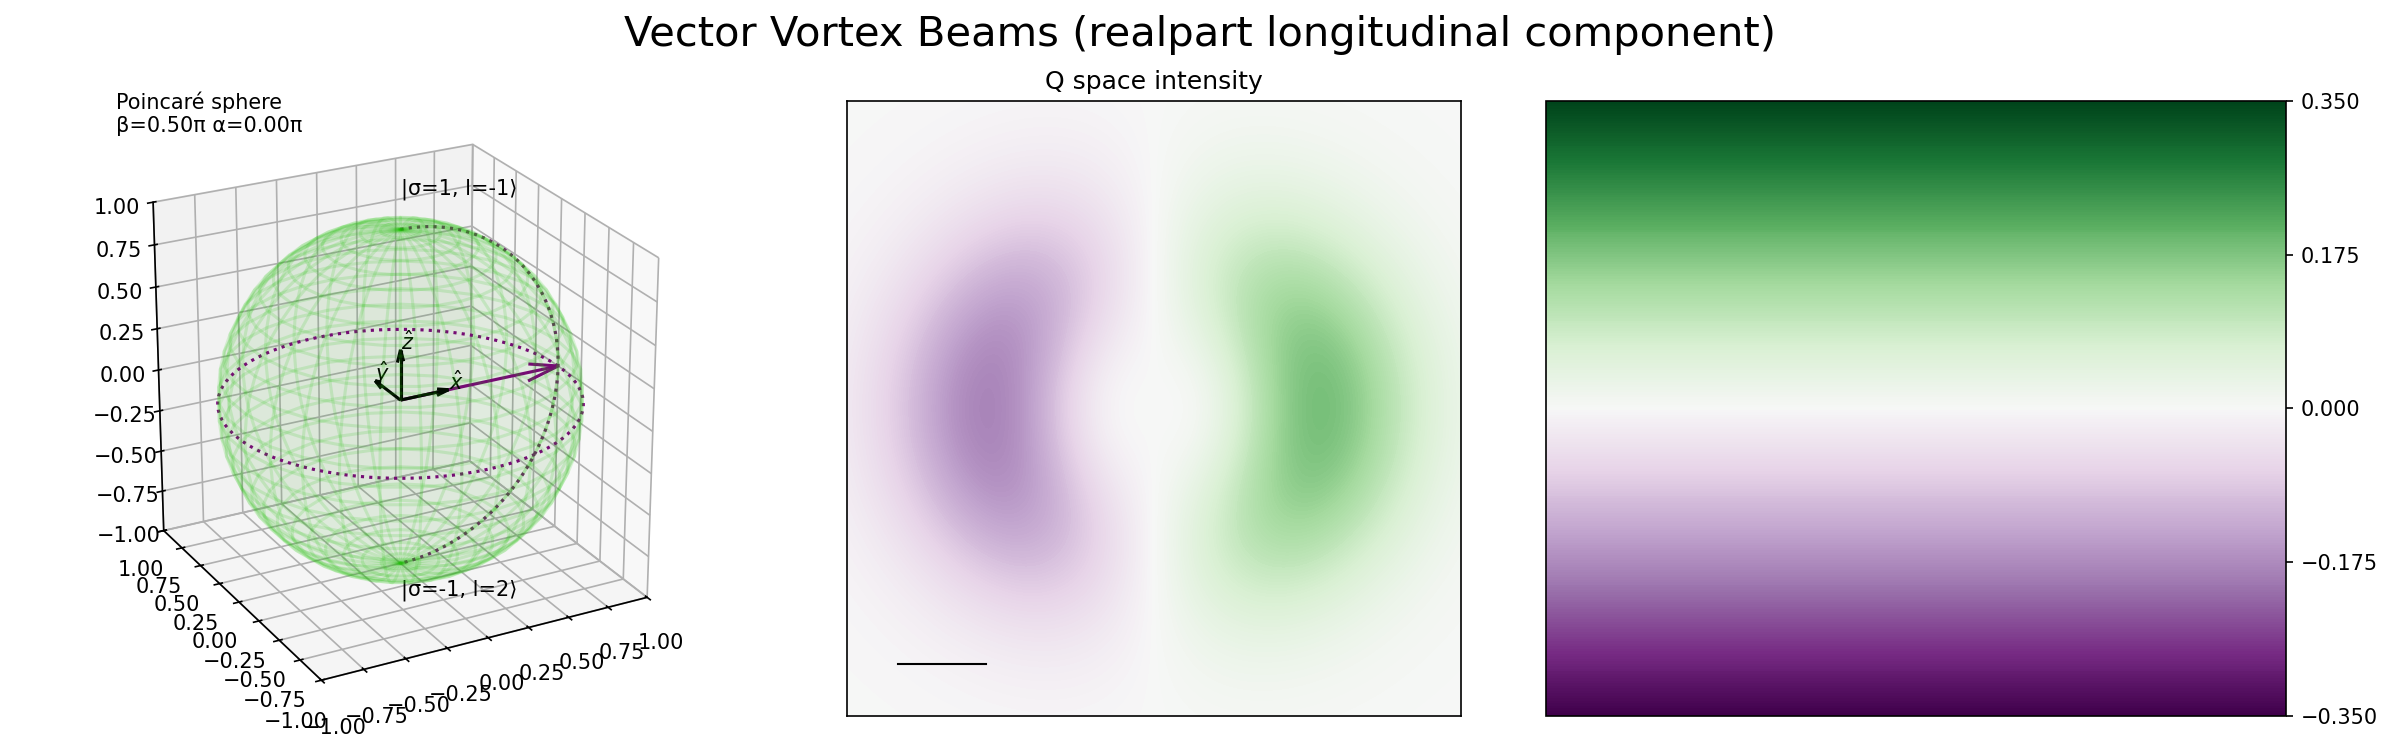

In [113]:
W, sigma1, sigma2 = 1.5, 1, -1
t = np.arange(0, 2*np.pi, 0.02)
circle, polar = np.linspace(0, 2*np.pi, 100), np.linspace(0, np.pi, 100)

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 6, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Sphere mesh
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx, sy, sz = np.cos(U)*np.sin(V), np.sin(U)*np.sin(V), np.cos(V)

# Layout & Widgets
fig = plt.figure(figsize=(16,5), dpi=150)

beta_slider = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
t_slider = widgets.FloatSlider(value=0, min=0, max=2, step=2/1000, description='Wt')
l1_box, l2_box, p_box = widgets.IntText(value=-1, description='l'), widgets.IntText(value=2, description="l'"), widgets.IntText(value=0, description='p')

LIMIT=0.35

def update_plot(l1, l2, p, beta, alpha, t):
    
    t=t*np.pi/w
    # t=np.pi/w * 1.75
    
    beta, alpha = beta * np.pi, alpha * np.pi
    
    # 徹底清除舊圖記憶，防止 3D quiver 與導引圓縮放異常
    fig.clear()
    
    # 重新建立子圖 (1, 3, i)
    ax3D = fig.add_subplot(1, 3, 1, projection='3d')
    ax_int = fig.add_subplot(1, 3, 2)
    cax = fig.add_subplot(1, 3, 3)
    
    ax3D.set_aspect('equal')
    ax_int.set_aspect('equal')

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(sx, sy, sz, color=(0.15,0.8,0.05,0.15))
    ax3D.plot_surface(sx, sy, sz, color=(0.15,0.8,0.05,0.05))
    
    qx, qy, qz = np.cos(alpha)*np.sin(beta), np.sin(alpha)*np.sin(beta), np.cos(beta)
    
    # 標示偏振態向量，限制箭頭比例 (arrow_length_ratio)
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    
    # 畫出三個標準黑色坐標軸
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    # 修正：使用正確的 'dotted' 純虛線樣式，無 'p' 標記
    ax3D.plot(np.sin(beta)*np.cos(circle), np.sin(beta)*np.sin(circle), np.cos(beta)+0*circle, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar)*np.cos(alpha), np.sin(polar)*np.sin(alpha), np.cos(polar), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩'); ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1,1); ax3D.set_ylim(-1,1); ax3D.set_zlim(-1,1); ax3D.view_init(24, -118)

    # ===================================================
    # 2. Intensity (Longitudinal component: VVBuz, Blues 色階)
    # ===================================================
    I = VVBuz(phiq, q, sigma1, sigma2, l1, l2, beta, alpha, t)
    
    TJ = (l2+l1+sigma2+sigma1)/2
    print('TJ=',TJ)
    
    contour = ax_int.contourf(X, Y, I, levels=np.linspace(-LIMIT, LIMIT, 250), cmap='PRGn')
    # contour = ax_int.contourf(X, Y, I, levels=np.linspace(0, 0.1, 100), cmap='PuRd')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    ax_int.set_title("Q space intensity"); ax_int.set_xticks([]); ax_int.set_yticks([]); ax_int.set_xlim(-3,3); ax_int.set_ylim(-3,3)

    plt.colorbar(contour, cax=cax, ticks=np.linspace(-LIMIT, LIMIT, 5))
    
    plt.suptitle("Vector Vortex Beams (realpart longitudinal component)", fontsize=20)
    plt.tight_layout()
    print(f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π')

out = widgets.interactive_output(update_plot, {'l1':l1_box, 'l2':l2_box, 'p':p_box, 'beta':beta_slider, 'alpha':alpha_slider, 't':t_slider})
ui = widgets.VBox([widgets.Label("coefficient"), widgets.HBox([l1_box, l2_box, p_box]), widgets.Label("parameter"), widgets.HBox([beta_slider, alpha_slider, t_slider])])
display(ui, out)